#**유통 판매량 예측 및 재고 최적화**
## **단계1 : 데이터 탐색 및 가설 도출**

# **0.미션**

* 예측해야 할 핵심상품 역할 분담
    * 핵심상품 별로, 데이터 탐색, 가설수립, 데이터셋 구성
    * 1인당 1~2개 정도를 분담하여 개별 과제 수행
    * 팀 미팅을 통해 진행 사항 공유 및 취합

* 데이터 탐색 및 가설 도출
    * 주어진 데이터에 대해 대상 매장, 대상 상품의 그래프 그리고 시계열 패턴을 찾기
    * 찾은 패턴을 기반으로 가설 도출

* 대상 상품(핵심 상품)

| Product_ID|Product_Code|SubCategory|Category|LeadTime|Price|
|----|----|----|----|----|----|
|3|DB001|Beverage|Drink|2|8|
|12|GA001|Milk|Food|3|6|
|42|FM001|Agricultural products|Grocery|3|5|


# **1.환경설정**

* 세부 요구사항
    * 구글콜랩
        * 구글 드라이브 바로 밑에 project 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 라이브러리 로딩
        * 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### **(1) 경로 설정**

* 구글 드라이브 연결

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
# path = '/content/drive/MyDrive/# KT aivle school/# 수업 코드/#16 Mini Project 6th/'
# c_path = '/content/'
# figpath = c_path +'figure/'
# first_ = True
# if first_ == True:
#   !pip install -qq geopandas

In [4]:
c_path = ''
figpath = './figure/'
path = './'
#path = '/content/drive/MyDrive/# KT aivle school/# 수업 코드/#16 Mini Project 6th/'

In [5]:
import os
os.makedirs(figpath, exist_ok=True)

### **(2) 라이브러리 설치 및 불러오기**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import MaxNLocator
import seaborn as sns

import joblib

from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

### **(3) 데이터 불러오기**

#### 1) 데이터로딩

In [10]:
oil_price = pd.read_csv(path + 'train/oil_price_train.csv')
orders = pd.read_csv(path + 'train/orders_train.csv')
sales = pd.read_csv(path + 'train/sales_train.csv')
products = pd.read_csv(path + 'train/products.csv')
stores = pd.read_csv(path + 'train/stores.csv')

sales['Date'] = pd.to_datetime(sales['Date'] )
oil_price['Date'] = pd.to_datetime(oil_price['Date'] )
orders['Date'] = pd.to_datetime(orders['Date'] )

#### 2) 기본 정보 조회

In [15]:
products.info()
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product_ID    16 non-null     int64 
 1   Product_Code  16 non-null     object
 2   SubCategory   16 non-null     object
 3   Category      16 non-null     object
 4   LeadTime      16 non-null     int64 
 5   Price         16 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 900.0+ bytes


,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price
0,20,HG001,Gardening Tools,Household Goods,2,50
1,27,HH001,Home Appliances,Household Goods,2,150
2,16,HK001,Kitchen,Household Goods,2,23
3,15,HK002,Kitchen,Household Goods,2,41
4,32,GS001,Seafood,Grocery,3,34


In [16]:
oil_price.info()
oil_price.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       825 non-null    datetime64[ns]
 1   WTI_Price  795 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 13.0 KB


,Date,WTI_Price
0,2014-01-01,NaN
1,2014-01-02,95.14
2,2014-01-03,93.66
3,2014-01-06,93.12
4,2014-01-07,93.31


In [17]:
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57558 entries, 0 to 57557
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           57558 non-null  datetime64[ns]
 1   Store_ID       57558 non-null  int64         
 2   CustomerCount  57558 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.3 MB


,Date,Store_ID,CustomerCount
0,2014-01-01,25,840
1,2014-01-01,36,487
2,2014-01-02,1,1875
3,2014-01-02,2,2122
4,2014-01-02,3,3350


In [18]:
sales.info()
sales.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934275 entries, 0 to 934274
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Date        934275 non-null  datetime64[ns]
 1   Store_ID    934275 non-null  int64         
 2   Qty         934275 non-null  float64       
 3   Product_ID  934275 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 28.5 MB


,Date,Store_ID,Qty,Product_ID
0,2014-01-01,1,0.0,3
1,2014-01-01,1,0.0,5
2,2014-01-01,1,0.0,7
3,2014-01-01,1,0.0,8
4,2014-01-01,1,0.0,10


In [19]:
stores.info()
stores['State'] = stores['State'].str.replace(r'\\', '', regex=True).str.strip()
stores.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Store_ID    54 non-null     int64 
 1   City        54 non-null     object
 2   State       54 non-null     object
 3   Store_Type  54 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 1.8+ KB


,Store_ID,City,State,Store_Type
0,1,Saint Paul,Minnesota,4
1,2,Saint Paul,Minnesota,4
2,3,Saint Paul,Minnesota,4
3,4,Saint Paul,Minnesota,4
4,5,Oklahoma City,Oklahoma,4


# **2.데이터 탐색**

* 시계열 패턴을 찾아보기 위한 그래프를 그려 봅시다.

## **(1) 시계열 패턴 찾아보기1**

* 다음 항목은 패턴을 찾기 위한 예제 문항 입니다. 참조하여 시계열 패턴을 찾아 봅시다.
    * 대상 매장(44), 대상 상품(3,12,42)의 판매량 추이
    * 대상 상품의 동일 카테고리의 상품별 판매량 추이
    * 휘발유 가격과 상품 판매량 추이 비교
    * 방문 고객수와 상품 판매량 추이 비교
    * 그외...

### 1) 대상 매장(44), 대상 상품의 판매량 추이

#### 함수

In [59]:
def plot_1_1(sales, store_id, product_id, sdate, edate, figpath):
    df = sales[(sales['Store_ID']==store_id) & (sales['Product_ID']==product_id)][['Date', 'Qty']]
    category = products[products['Product_ID']==product_id]['SubCategory'].values[0]
    df = df.set_index(['Date'])

    con1 = (df.index.month==1)
    con2 = (df.index.day==1)
    df_temp = df.loc[con1 & con2]
    con_f = df_temp['Qty'].sum()
    if con_f == 0:
        df_mean = df['Qty'].resample('MS').mean()
        df_temp2 = df_mean.loc[df_temp.index]
        df['Qty'].loc[con1 & con2] = pd.DataFrame(df_temp2.loc[df_temp2.index])['Qty']
    df = df.loc[sdate:edate]

    # 일단위 plot
    plt.figure(figsize=(10, 3))
    plt.plot(df['Qty'], marker='o', linestyle='-', color='b', linewidth=0.5, markersize = 3)
    plt.title(f'{category}_Daily', fontsize=14, weight='bold')
    for year in df.index.year.unique():
        plt.axvline(pd.Timestamp(f'{year}-01-01'), color='green', linestyle='--', linewidth=1.5) # 연도별 구분선 추가
    ax = plt.gca()
    xticks = ax.get_xticks()
    xticks_dates = [mdates.num2date(tick).strftime('%Y-%m-%d') for tick in xticks]
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3, bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    xticks_dates[-1] = (f'{edate[:-3]}-01')
    plt.xticks(xticks_dates, fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel('Date')
    plt.ylabel('Qty')
    plt.grid(True)
    plt.savefig(f'{figpath}/{category}_Daily.png')
    plt.show()
    plt.close()

    # 월 단위 plot
    df_M = df['Qty'].resample('MS').mean()
    plt.figure(figsize=(10, 3))
    plt.plot(df_M, marker='o', linestyle='-', color='b')
    plt.title(f'{category}_Month',fontsize=14, weight='bold')
    # 연도별 구분선 추가
    for year in df_M.index.year.unique():
        plt.axvline(pd.Timestamp(f'{year}-01-01'), color='green', linestyle='--', linewidth=0.5, markersize=3) # 연도별 구분선 추가
    ax = plt.gca()
    xticks = ax.get_xticks()
    xticks_dates = [mdates.num2date(tick).strftime('%Y-%m-%d') for tick in xticks]
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3, bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    xticks_dates[-1] = (f'{edate[:-3]}-01')
    plt.xticks(xticks_dates, fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel('Date')
    plt.ylabel('Qty')
    plt.grid(True)
    plt.savefig(f'{figpath}/{category}_Month.png')
    plt.show()
    plt.close()

    # 연 단위 plot\
    df_Y = pd.DataFrame(df['Qty'].resample('YS').mean())
    df_Y['Year'] = df_Y.index.strftime('%Y')
    df_Y = df_Y.iloc[:-1]
    plt.figure(figsize=(10, 3))
    sns.barplot(x='Qty', y='Year', data = df_Y, color='b')
    plt.title(f'{category}_Year',fontsize=14, weight='bold')
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel('Qty')
    plt.ylabel('Date')
    plt.grid(True)
    plt.savefig(f'{figpath}/{category}_Year.png')
    plt.show()
    plt.close()
    return df

#### 데이터 별 결과

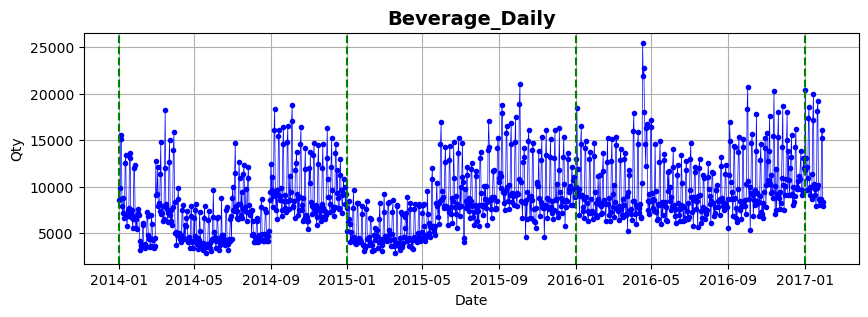

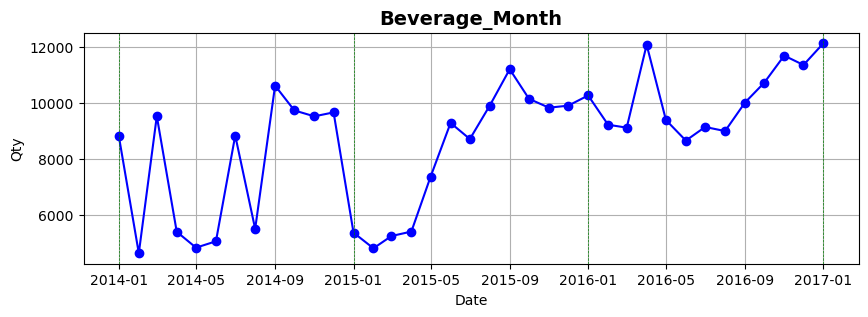

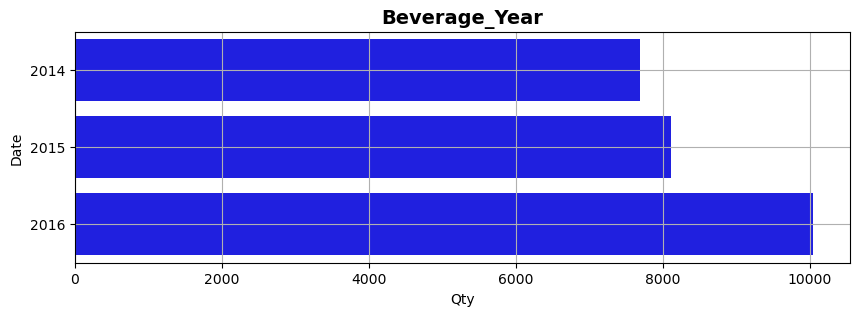

In [62]:
store_id = 44
product_id = 3
sdate = '2014-01-01'
edate = '2017-01-31'
df_Bev = plot_1_1(sales, store_id, product_id, sdate, edate, figpath)

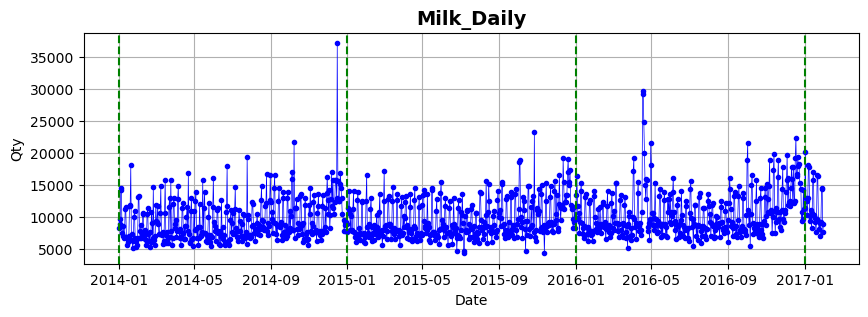

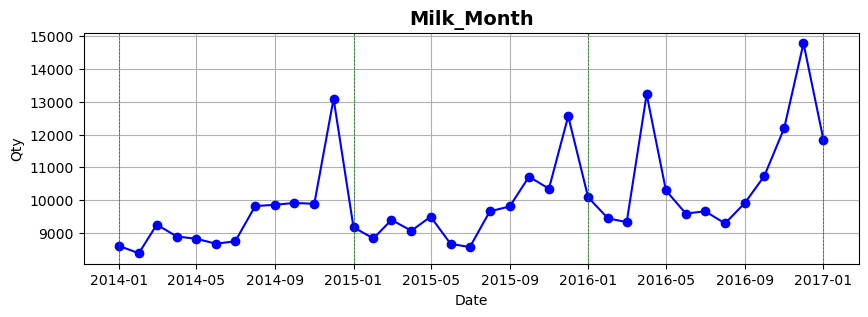

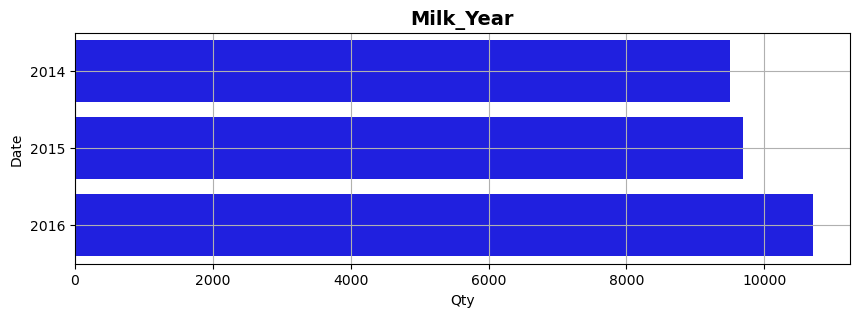

In [63]:
store_id = 44
product_id = 12
sdate = '2014-01-01'
edate = '2017-01-31'
df_Milk = plot_1_1(sales, store_id, product_id, sdate, edate, figpath)

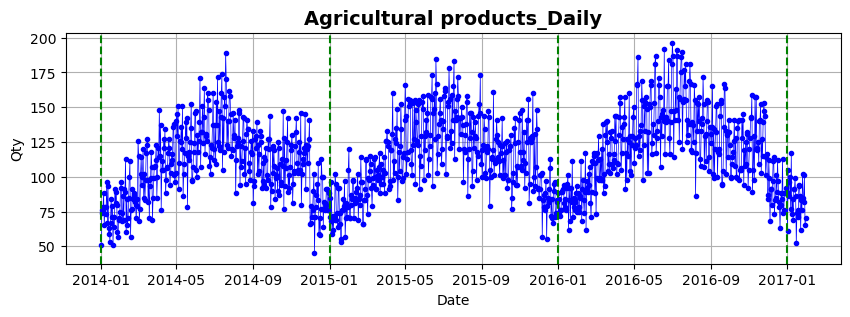

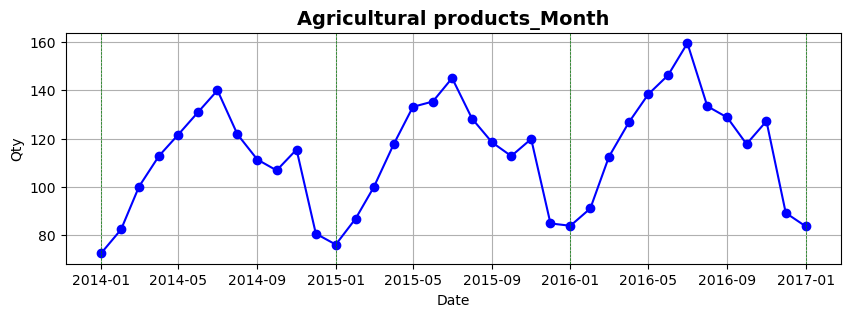

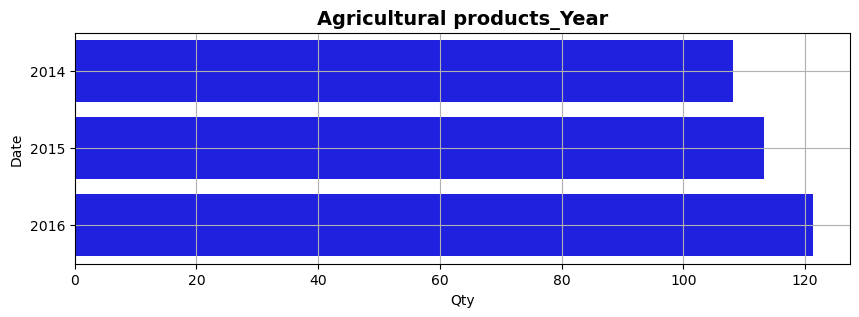

In [64]:
store_id = 44
product_id = 42
sdate = '2014-01-01'
edate = '2017-01-31'
df_Agr = plot_1_1(sales, store_id, product_id, sdate, edate, figpath)

In [106]:
null_date = [f'201{i}-12-25' for i in range(4,7)]
temp_df = pd.DataFrame(index = df_Agr.index, columns=df_Bev.columns)
temp_df['Qty'] = np.NaN
temp_df['Qty'] = df_Bev['Qty']
temp_df['Qty'] = temp_df['Qty'].interpolate(method='linear')
df_Bev = temp_df.copy()

In [108]:
null_date = [f'201{i}-12-25' for i in range(4,7)]
temp_df = pd.DataFrame(index = df_Agr.index, columns=df_Milk.columns)
temp_df['Qty'] = np.NaN
temp_df['Qty'] = df_Milk['Qty']
temp_df['Qty'] = temp_df['Qty'].interpolate(method='linear')
df_Milk = temp_df.copy()

### 2) 대상 상품의 동일 카테고리의 상품별 판매량 추이

#### 함수

In [ ]:
sales

In [299]:
def plot_1_2(target, products, sales, sdate, edate, figpath):
    prod_target = products[products['Category']==target]
    id_list = prod_target['Product_ID'].tolist()
    names = prod_target['SubCategory'].tolist()

    temp = sales[(sales['Store_ID']==44) & (sales['Product_ID'].isin(id_list))][['Date', 'Qty', 'Product_ID']]
    df2 = temp.groupby(['Date', 'Product_ID']).sum().reset_index()
    df2 = df2.pivot(index='Date', columns='Product_ID', values='Qty')
    df2.columns = names
    data = df2.loc[sdate:edate]

    df = data.copy()
    for col in names:
        con1 = (df.index.month==1)
        con2 = (df.index.day==1)
        df_temp = df.loc[con1 & con2]
        con_f = df_temp[col].sum()
        if con_f == 0:
            df_mean = df[col].resample('MS').mean()
            df_temp2 = df_mean.loc[df_temp.index]
            df[col].loc[con1 & con2] = pd.DataFrame(df_temp2.loc[df_temp2.index])[col]
        data[col] = df[col].loc[sdate:edate]

    df2_s = MinMaxScaler().fit_transform(data)
    df2_s = pd.DataFrame(df2_s, columns=names, index=data.index)
    df2_s_M = df2_s[names].resample('MS').mean()

    plt.figure(figsize=(10,4))
    for col in names:
        plt.plot(df2_s[col], label=col, marker='o', linestyle='-', linewidth=0.5,markersize=3)
    for year in df2_s.index.year.unique():
        plt.axvline(pd.Timestamp(f'{year}-01-01'), color='green', linestyle='--', linewidth=1.5) # 연도별 구분선 추가
        ax = plt.gca()
        xticks = ax.get_xticks()
        xticks_dates = [mdates.num2date(tick).strftime('%Y-%m-%d') for tick in xticks]
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3, bymonth=[1, 4, 7, 10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        xticks_dates[-1] = (f'{edate[:-3]}-01')
        plt.xticks(xticks_dates, fontsize=10)
        plt.yticks(fontsize=10)
        plt.xlabel('Qty')
        plt.ylabel('Date')
    plt.legend()
    plt.grid(True)
    plt.title('Daily_Scaled')
    plt.tight_layout()
    plt.savefig(f'{figpath}/{target}_Daily_scaled.png')
    plt.show()
    plt.close()

    plt.figure(figsize=(10,4))
    for col in names:
        plt.plot(df2_s_M[col], label=col, marker='o', linestyle='-', linewidth=0.5,markersize=3)
    for year in df2_s_M.index.year.unique():
        plt.axvline(pd.Timestamp(f'{year}-01-01'), color='green', linestyle='--', linewidth=1.5) # 연도별 구분선 추가
        ax = plt.gca()
        xticks = ax.get_xticks()
        xticks_dates = [mdates.num2date(tick).strftime('%Y-%m-%d') for tick in xticks]
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3, bymonth=[1, 4, 7, 10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        xticks_dates[-1] = (f'{edate[:-3]}-01')
        plt.xticks(xticks_dates, fontsize=10)
        plt.yticks(fontsize=10)
        plt.xlabel('Qty')
        plt.ylabel('Date')
    plt.legend()
    plt.grid(True)
    plt.title('Year_Scaled')
    plt.tight_layout()
    plt.savefig(f'{figpath}/{target}_Year_scaled.png')
    plt.show()
    plt.close()


    plt.figure(figsize=(10,4))
    sns.boxplot(data=df2_s)
    plt.title('Box Plot')
    plt.savefig(f'{figpath}/{target}_box.png')
    plt.show()
    plt.close()

    plt.figure(figsize=(5, 4))
    sns.heatmap(abs(data.corr()), vmax=1, vmin=0, annot=True, cmap='gist_yarg', center=0)
    plt.title('Pearson corr.')
    plt.savefig(f'{figpath}/{target}_heatmap_pearson.png')
    plt.show()
    plt.close()

    '''plt.figure(figsize=(5, 4))
    sns.heatmap(data.corr(method='spearman'), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
    plt.title('Spearman corr.')
    plt.savefig(f'{figpath}/{target}_heatmap_spearman.png')
    plt.show()
    plt.close()'''
    return data

#### 데이터 별 결과

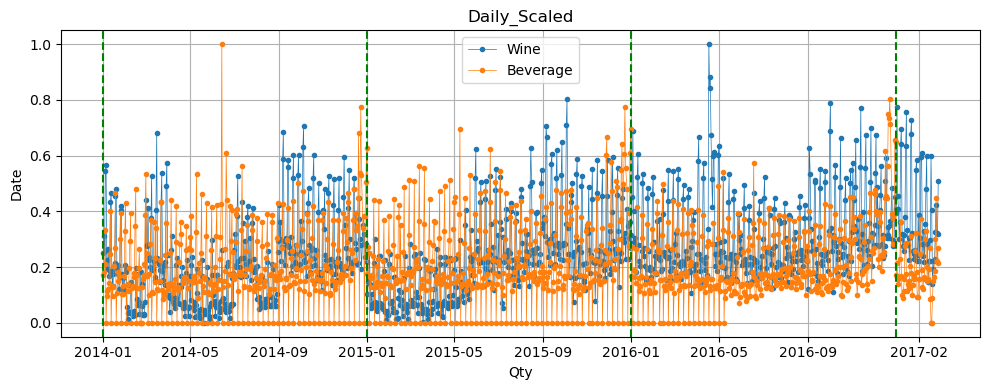

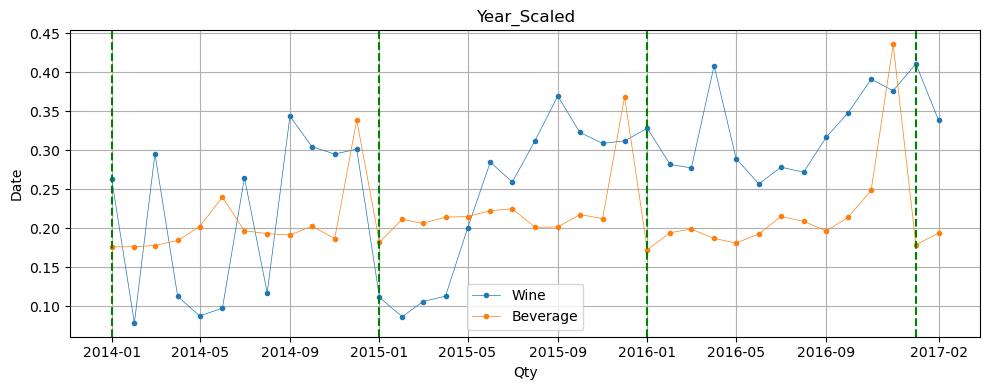

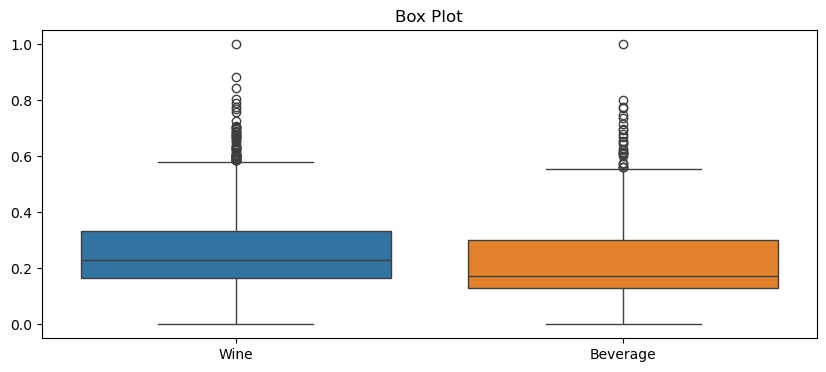

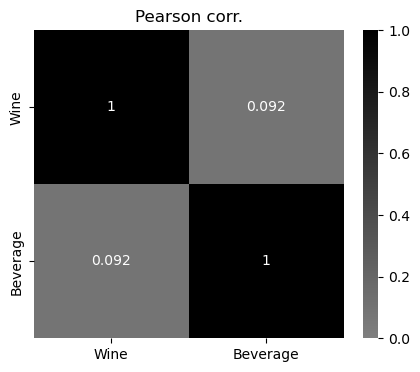

In [302]:
target = 'Drink'
data2 = plot_1_2(target, products, sales, sdate, edate, figpath)

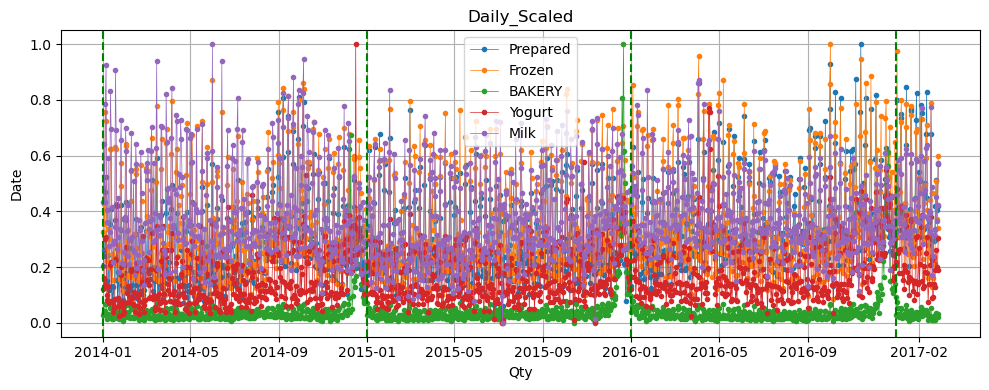

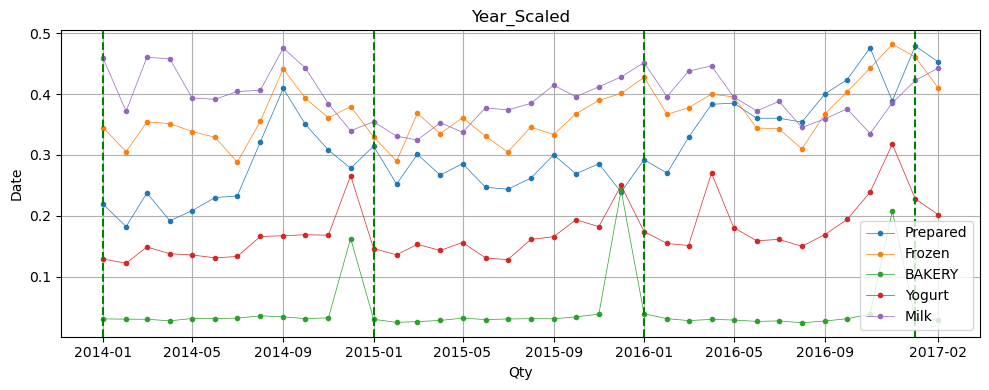

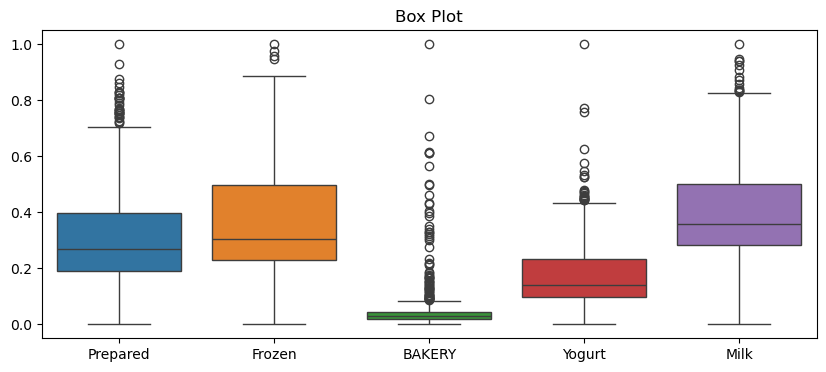

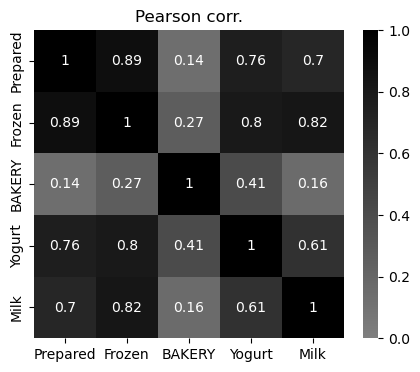

In [304]:
target = 'Food'
data2 = plot_1_2(target, products, sales, sdate, edate, figpath)

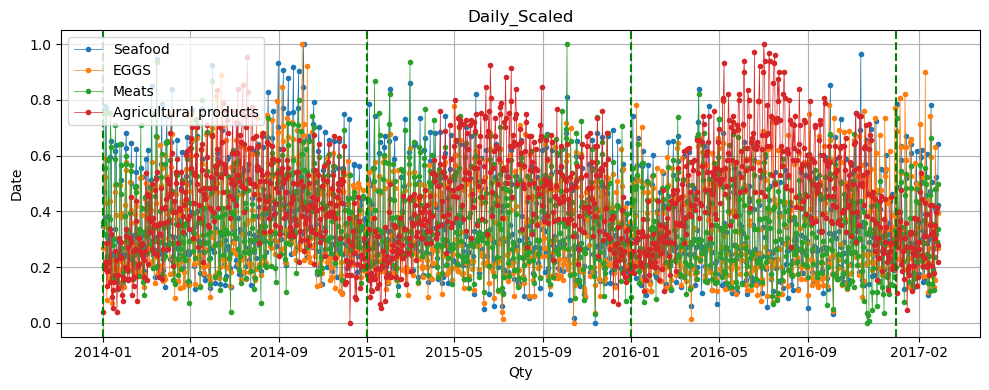

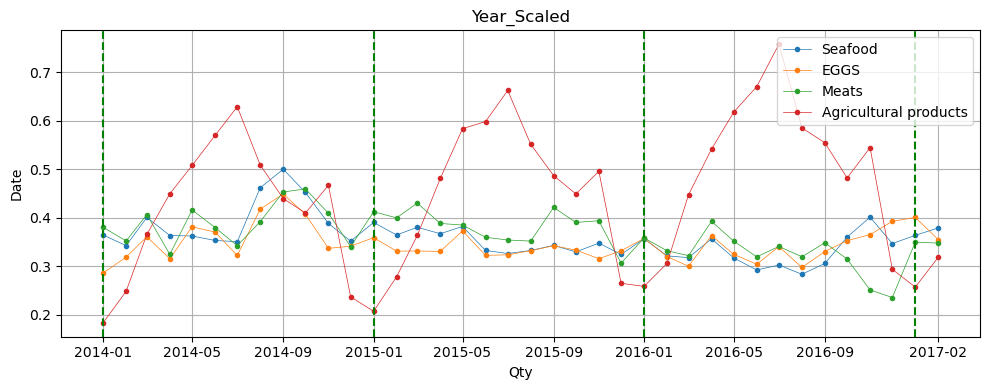

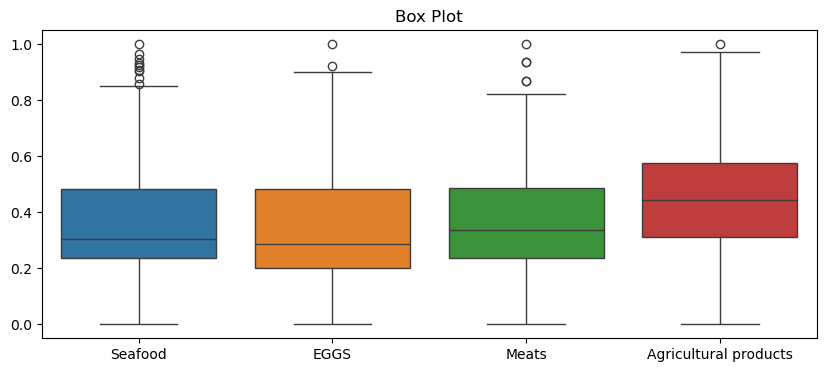

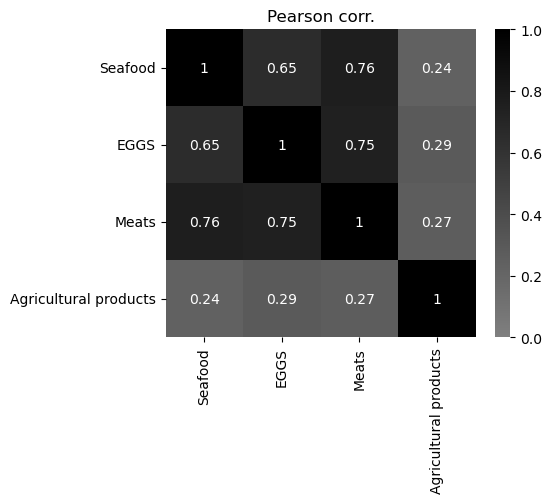

In [305]:
target = 'Grocery'
data = plot_1_2(target, products, sales, sdate, edate,figpath)

### 3) 휘발유 가격과 상품 판매량 추이 비교

#### 함수

In [308]:
def plot_1_3(oil_price, products, product_id, df, figpath):
    category = products[products['Product_ID']==product_id]['SubCategory'].values[0]
    oil_price = oil_price.set_index('Date')
    df3 = df.copy()
    df3['WTI_Price'] = oil_price['WTI_Price']
    df3['WTI_Price'] = df3['WTI_Price'].interpolate(method='linear')
    df3['WTI_Price'].iloc[0] = df3['WTI_Price'].iloc[1]

    df3_ = MinMaxScaler().fit_transform(df3)
    df3_ = pd.DataFrame(df3_, columns=df3.columns, index=df3.index)
    df3_ = df3_.loc[sdate:edate]

    names = ['Qty', 'WTI_Price']

    plt.figure(figsize=(16, 4))
    # 첫 번째 y축 (판매량)
    plt.plot(df3_['Qty'], marker='o', linestyle='-', color='b', label=f'{category}_Qty',linewidth=0.5,markersize=0.3)
    # 두 번째 y축 (방문 고객수)
    plt.plot(df3_['WTI_Price'],  marker='x', linestyle='-', color='r', label='WTI_Price',linewidth=0.5,markersize=0.3)
    plt.title(f'{category}_Daily', fontsize=14, weight='bold')
    for year in df.index.year.unique():
        plt.axvline(pd.Timestamp(f'{year}-01-01'), color='green', linestyle='--', linewidth=1.5) # 연도별 구분선 추가
    ax = plt.gca()
    xticks = ax.get_xticks()
    xticks_dates = [mdates.num2date(tick).strftime('%Y-%m-%d') for tick in xticks]
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3, bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    xticks_dates[-1] = (f'{edate[:-3]}-01')
    plt.title('Daily')
    plt.xticks(xticks_dates, fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel('Date')
    plt.ylabel('Min Max Scaled')
    plt.grid(True)
    plt.savefig(f'{figpath}/{category}_Oil_Daily.png')
    plt.show()
    plt.close()

    df_M = df3_[['Qty', 'WTI_Price']].resample('MS').mean()
    plt.figure(figsize=(16, 4))
    # 첫 번째 y축 (판매량)
    plt.plot(df_M['Qty'], marker='o', linestyle='-', color='b', label=f'{category}_Qty',linewidth=0.5,markersize=0.3)
    # 두 번째 y축 (방문 고객수)
    plt.plot(df_M['WTI_Price'],  marker='x', linestyle='-', color='r', label='WTI_Price',linewidth=0.5,markersize=0.3)
    plt.title(f'{category}_Daily', fontsize=14, weight='bold')
    for year in df.index.year.unique():
        plt.axvline(pd.Timestamp(f'{year}-01-01'), color='green', linestyle='--', linewidth=1.5) # 연도별 구분선 추가
    ax = plt.gca()
    xticks = ax.get_xticks()
    xticks_dates = [mdates.num2date(tick).strftime('%Y-%m-%d') for tick in xticks]
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3, bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    xticks_dates[-1] = (f'{edate[:-3]}-01')
    plt.title('Month')
    plt.xticks(xticks_dates, fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel('Date')
    plt.ylabel('Min Max Scaled')
    plt.grid(True)
    plt.savefig(f'{figpath}/{category}_Oil_Month.png')
    plt.show()
    plt.close()

    plt.figure(figsize=(10,4))
    sns.boxplot(data=df3_)
    plt.title('Box Plot')
    plt.savefig(f'{figpath}/{target}_box.png')
    plt.show()
    plt.close()

    plt.figure(figsize=(5, 4))
    sns.heatmap(abs(df3_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
    plt.title('Pearson corr.')
    plt.savefig(f'{figpath}/{target}_heatmap_pearson.png')
    plt.show()
    plt.close()

    '''plt.figure(figsize=(5, 4))
    sns.heatmap(df3_.corr(method='spearman'), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
    plt.title('Spearman corr.')
    plt.savefig(f'{figpath}/{target}_heatmap_spearman.png')
    plt.show()
    plt.close()'''

#### 데이터 별 결과

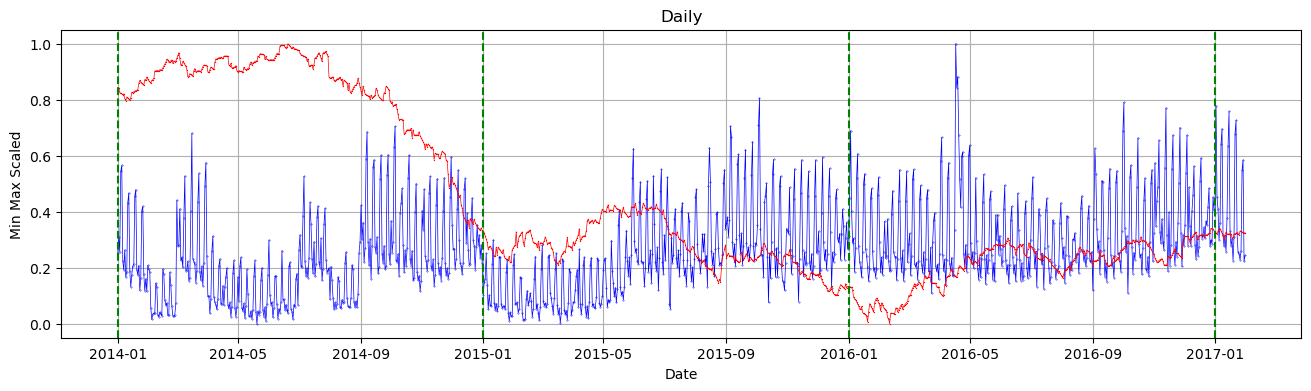

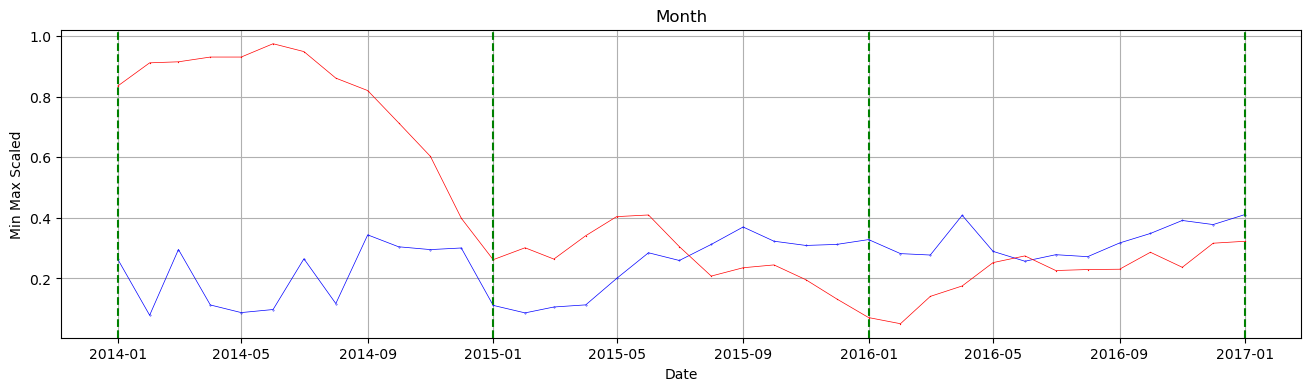

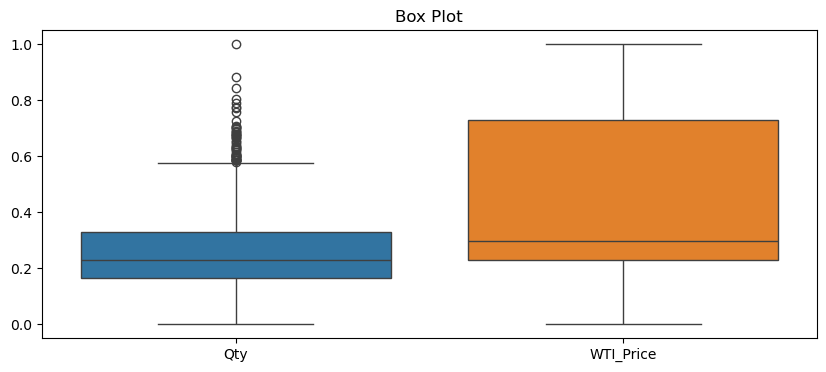

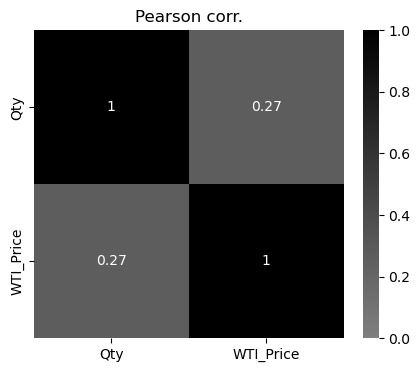

In [311]:
oil_price_ = oil_price.copy()
store_id = 44
product_id = 3
sdate = '2014-01-01'
edate = '2017-01-31'
plot_1_3(oil_price_, products, product_id, df_Bev,figpath)

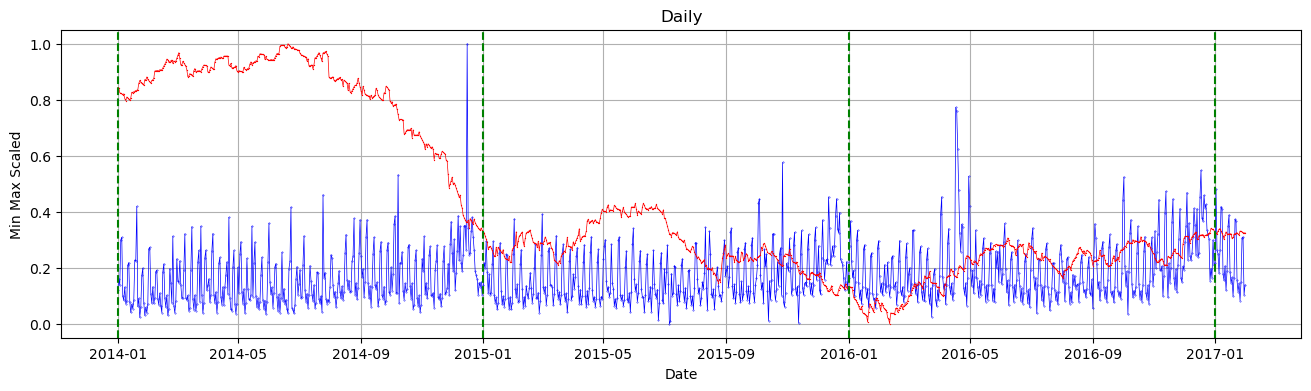

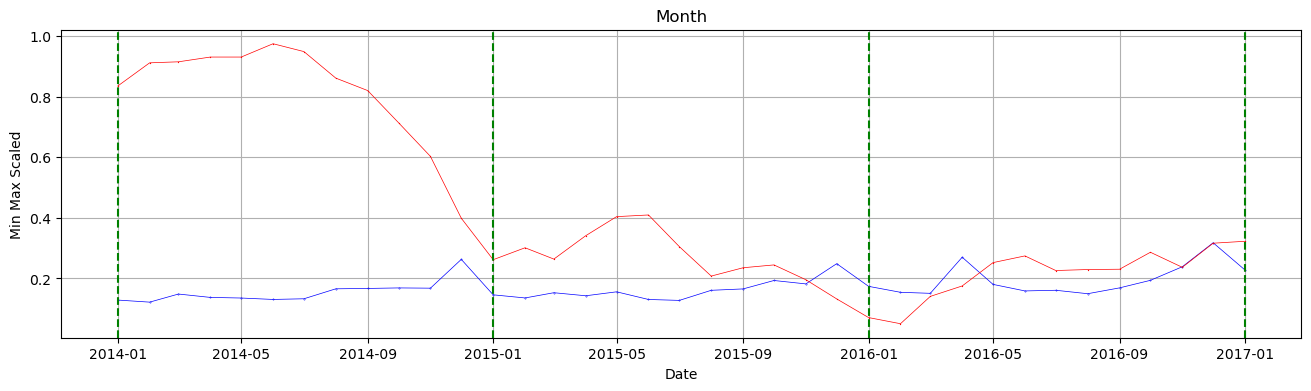

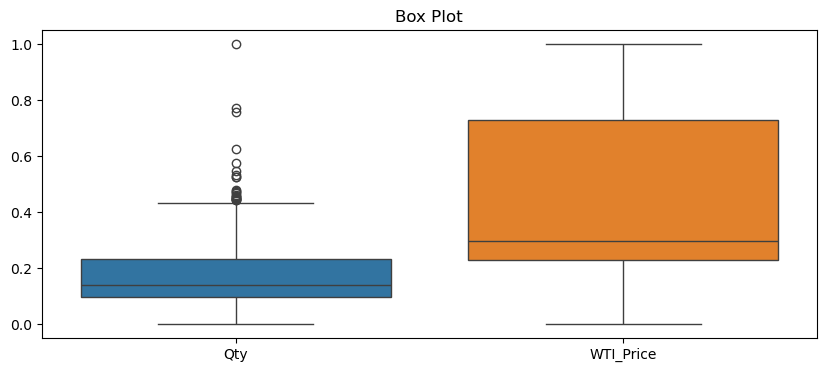

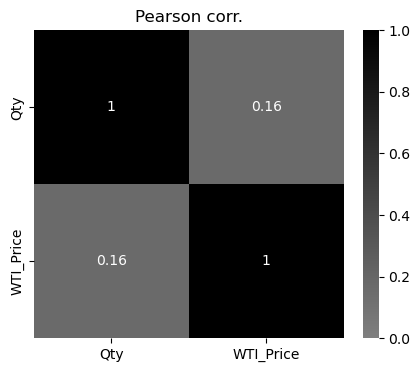

In [313]:
oil_price_ = oil_price.copy()
store_id = 12
product_id = 42
sdate = '2014-01-01'
edate = '2017-01-31'
plot_1_3(oil_price_, products, product_id, df_Milk,figpath)

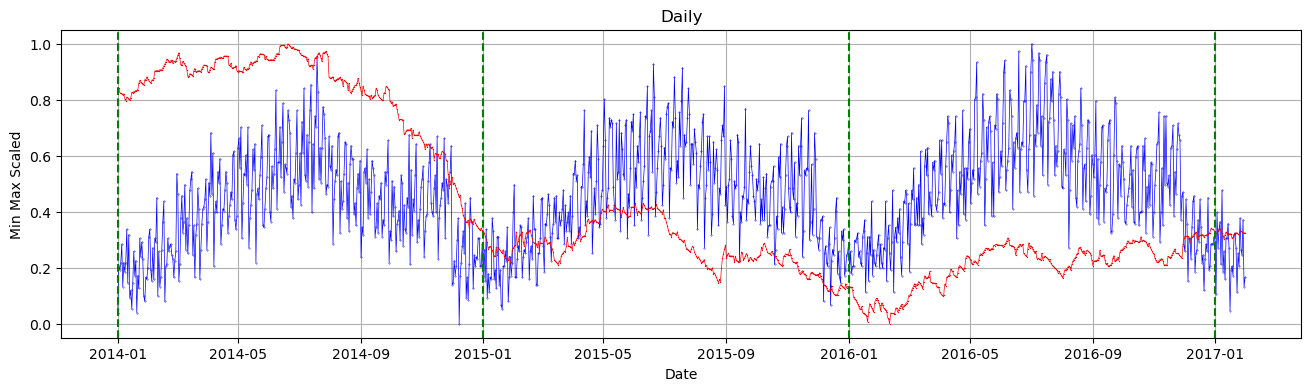

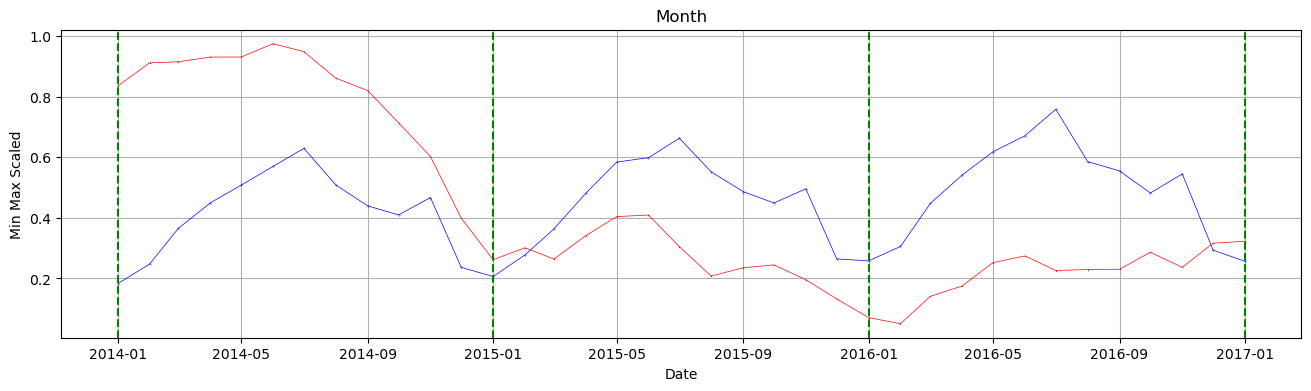

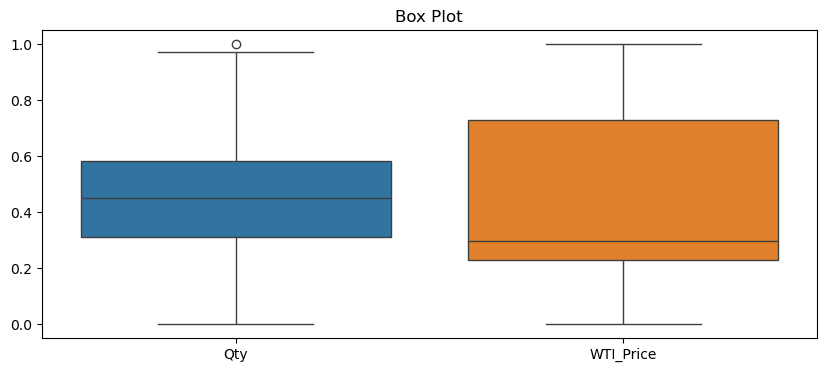

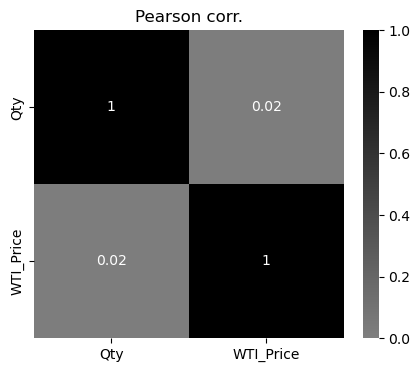

In [315]:
_price_ = oil_price.copy()
store_id = 12
product_id = 42
sdate = '2014-01-01'
edate = '2017-01-31'
plot_1_3(oil_price_, products, product_id, df_Agr,figpath)

### 4) 방문 고객수와 상품 판매량 추이 비교

#### 함수

In [322]:
orders_ = orders.copy()
store_id = 44
product_id = 3
sdate = '2014-01-01'
edate = '2017-01-31'

def plot_1_4(orders, products, store_id, product_id, sdate, edate, df,figpath):
    category = products[products['Product_ID']==product_id]['SubCategory'].values[0]
    temp = orders[orders['Store_ID']==store_id].set_index('Date')
    df3 = df.copy()
    df3['CustomerCount'] = temp['CustomerCount']
    df3['CustomerCount'] = df3['CustomerCount'].interpolate(method='linear')
    df3['CustomerCount'].iloc[0] = df3['CustomerCount'].iloc[1]
    df3 = df3.loc[sdate:edate]

    df3_ = MinMaxScaler().fit_transform(df3)
    df3_ = pd.DataFrame(df3_, columns=df3.columns, index=df3.index)

    plt.figure(figsize=(16, 4))
    # 첫 번째 y축 (판매량)
    plt.plot(df3_['Qty'], marker='o', linestyle='-', color='b', label=f'{category}_Qty',markersize=3,linewidth=0.5)
    # 두 번째 y축 (방문 고객수)
    plt.plot(df3_['CustomerCount'],  marker='x', linestyle='-', color='r', label='CustomerCount')
    plt.title(f'{category}_Daily', fontsize=14, weight='bold')
    for year in df.index.year.unique():
        plt.axvline(pd.Timestamp(f'{year}-01-01'), color='green', linestyle='--', linewidth=1.5) # 연도별 구분선 추가
    ax = plt.gca()
    xticks = ax.get_xticks()
    xticks_dates = [mdates.num2date(tick).strftime('%Y-%m-%d') for tick in xticks]
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3, bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    xticks_dates[-1] = (f'{edate[:-3]}-01')
    plt.title('Daily')
    plt.xticks(xticks_dates, fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel('Date')
    plt.ylabel('Min Max Scaled')
    plt.grid(True)
    plt.savefig(f'{figpath}/{category}_CustomerCount_Daily.png')
    plt.show()
    plt.close()

    df_M = df3_[['Qty', 'CustomerCount']].resample('MS').mean()
    plt.figure(figsize=(16, 4))
    # 첫 번째 y축 (판매량)
    plt.plot(df_M['Qty'], marker='o', linestyle='-', color='b', label=f'{category}_Qty',markersize=3,linewidth=0.5)
    # 두 번째 y축 (방문 고객수)
    plt.plot(df_M['CustomerCount'],  marker='x', linestyle='-', color='r', label='CustomerCount')
    plt.title(f'{category}_Daily', fontsize=14, weight='bold')
    for year in df.index.year.unique():
        plt.axvline(pd.Timestamp(f'{year}-01-01'), color='green', linestyle='--', linewidth=1.5) # 연도별 구분선 추가
    ax = plt.gca()
    xticks = ax.get_xticks()
    xticks_dates = [mdates.num2date(tick).strftime('%Y-%m-%d') for tick in xticks]
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3, bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    xticks_dates[-1] = (f'{edate[:-3]}-01')
    plt.title('Month')
    plt.xticks(xticks_dates, fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel('Date')
    plt.ylabel('Min Max Scaled')
    plt.grid(True)
    plt.savefig(f'{figpath}{category}_CustomerCount_Month.png')
    plt.show()
    plt.close()

    plt.figure(figsize=(10,4))
    sns.boxplot(data=df3_)
    plt.title('Box Plot')
    plt.savefig(f'{figpath}{category}_CustomerCount_box.png')
    plt.show()
    plt.close()

    plt.figure(figsize=(5, 4))
    sns.heatmap(abs(df3_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
    plt.title('Pearson corr.')
    plt.savefig(f'{figpath}{category}_CustomerCount_heatmap_pearson.png')
    plt.show()
    plt.close()

    '''plt.figure(figsize=(5, 4))
    sns.heatmap(df3_.corr(method='spearman'), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
    plt.title('Spearman corr.')
    plt.savefig(f'{figpath}{category}_CustomerCount_heatmap_spearman.png')
    plt.show()
    plt.close()'''

#### 데이터 별 결과

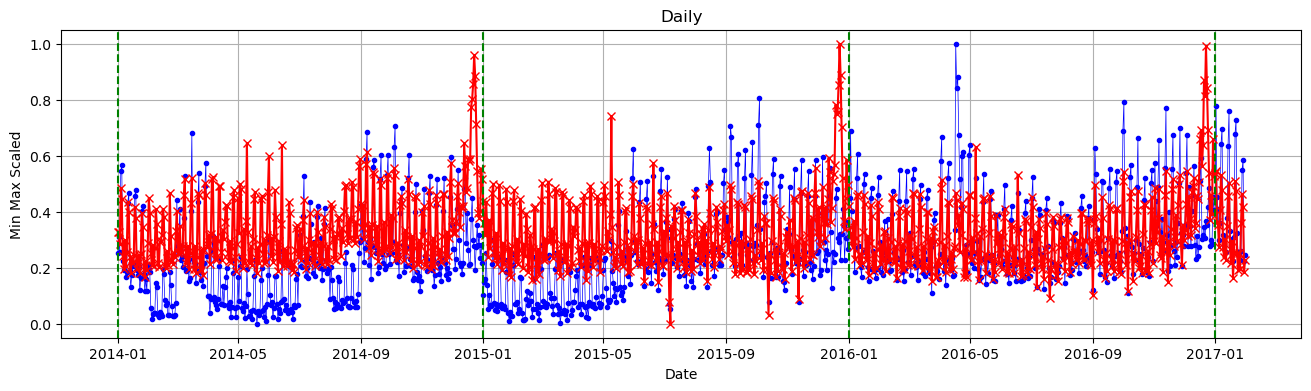

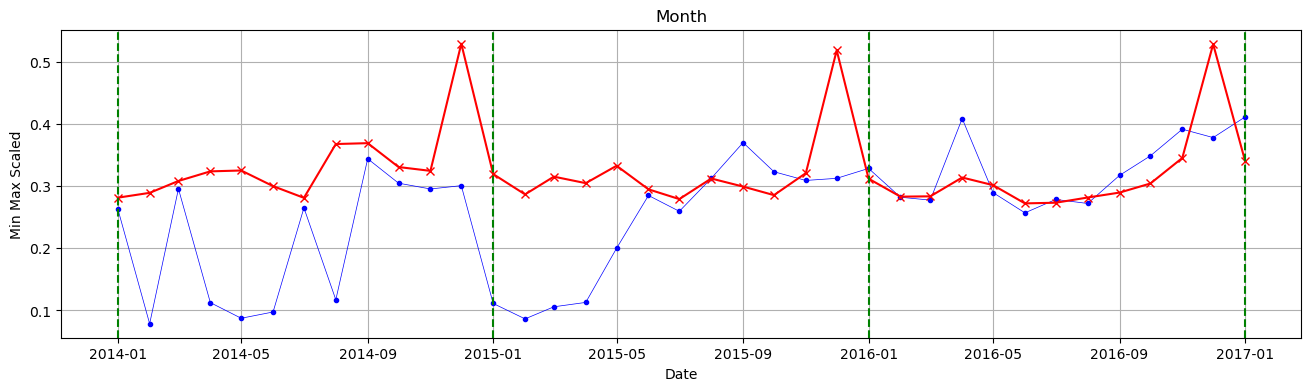

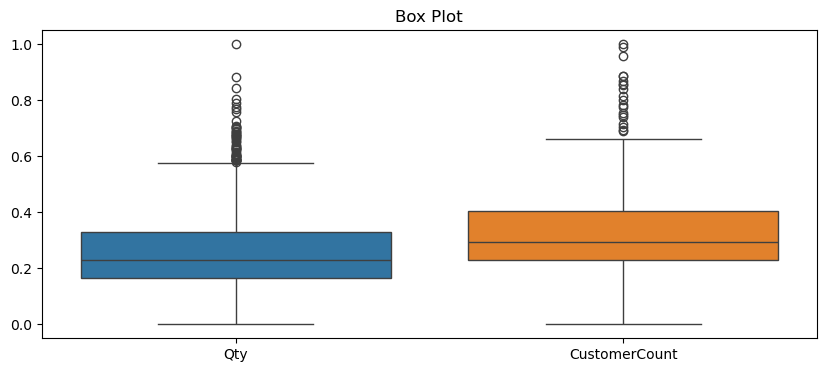

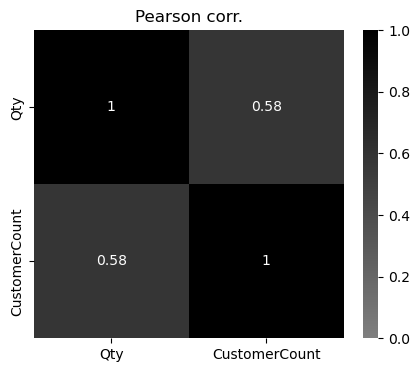

In [325]:
orders_ = orders.copy()
store_id = 44
product_id = 3
sdate = '2014-01-01'
edate = '2017-01-31'
plot_1_4(orders_, products, store_id, product_id, sdate, edate, df_Bev,figpath)

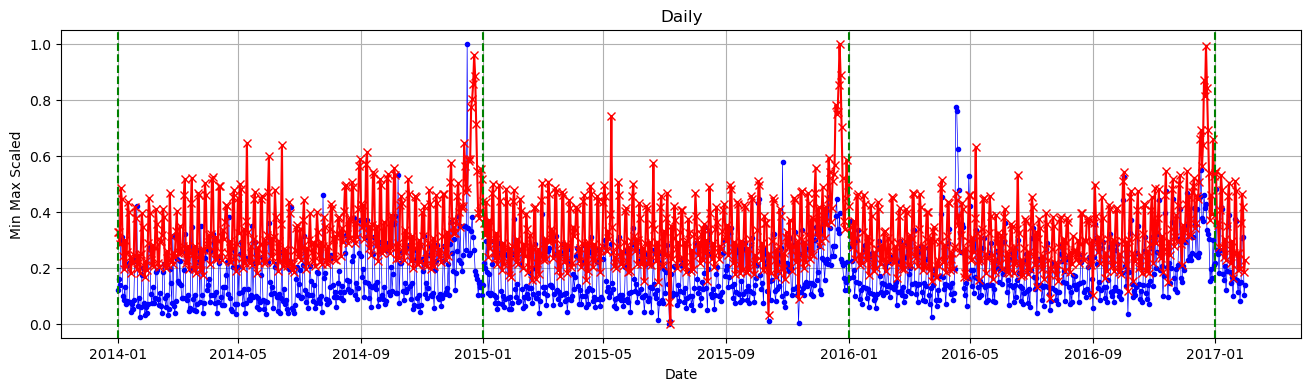

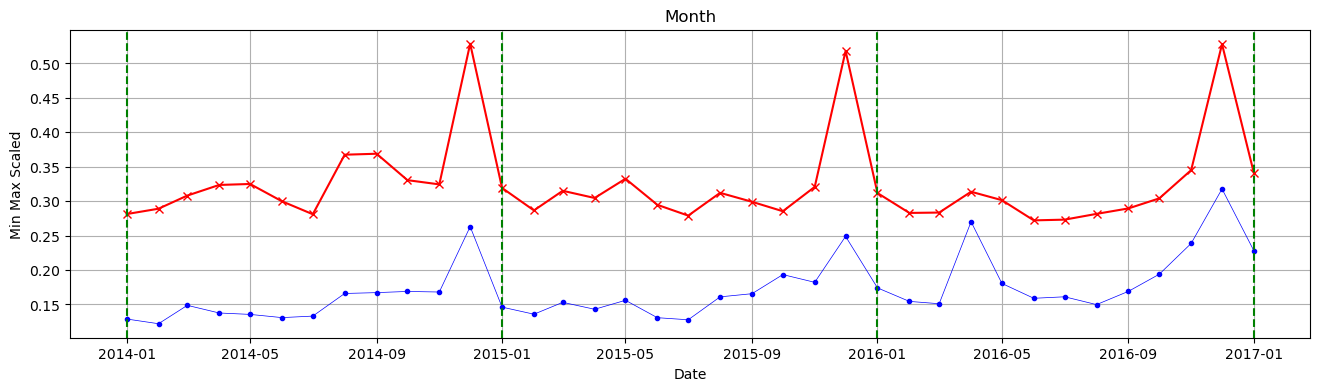

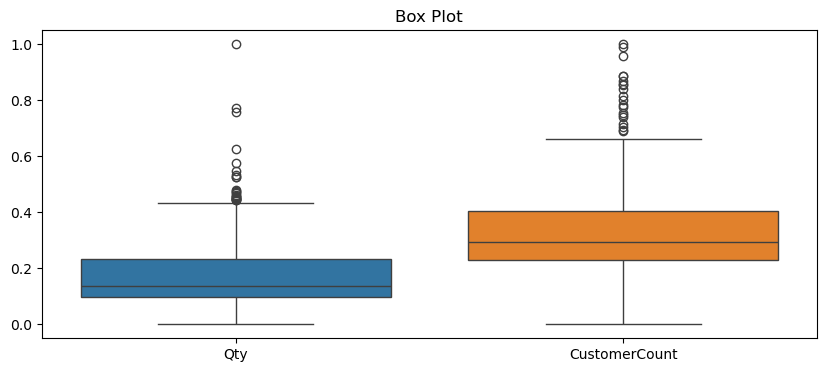

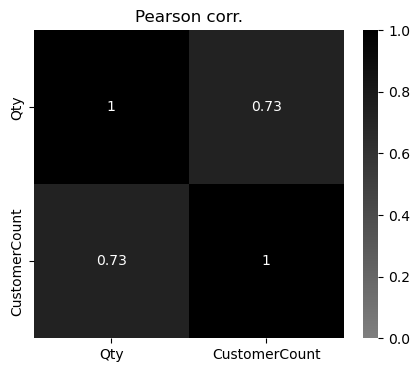

In [327]:
orders_ = orders.copy()
store_id = 44
product_id = 12
sdate = '2014-01-01'
edate = '2017-01-31'
plot_1_4(orders_, products, store_id, product_id, sdate, edate, df_Milk,figpath)

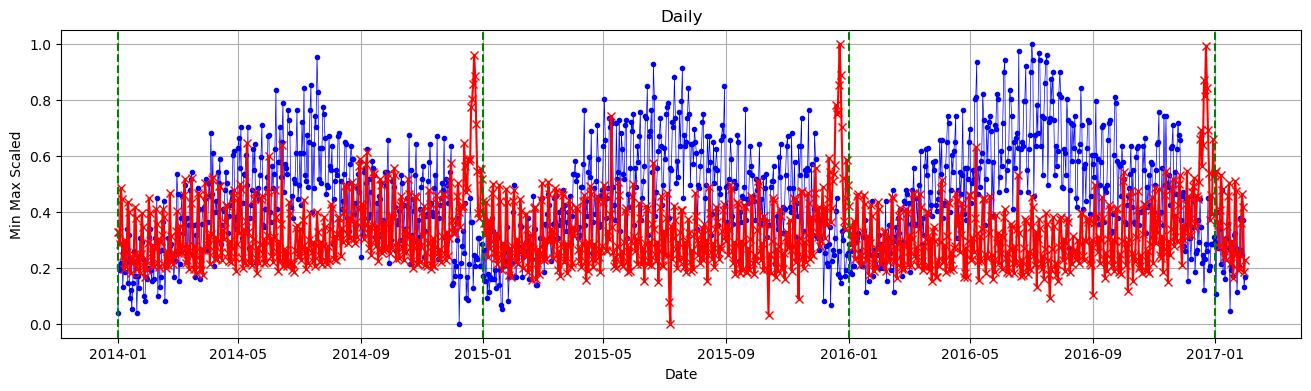

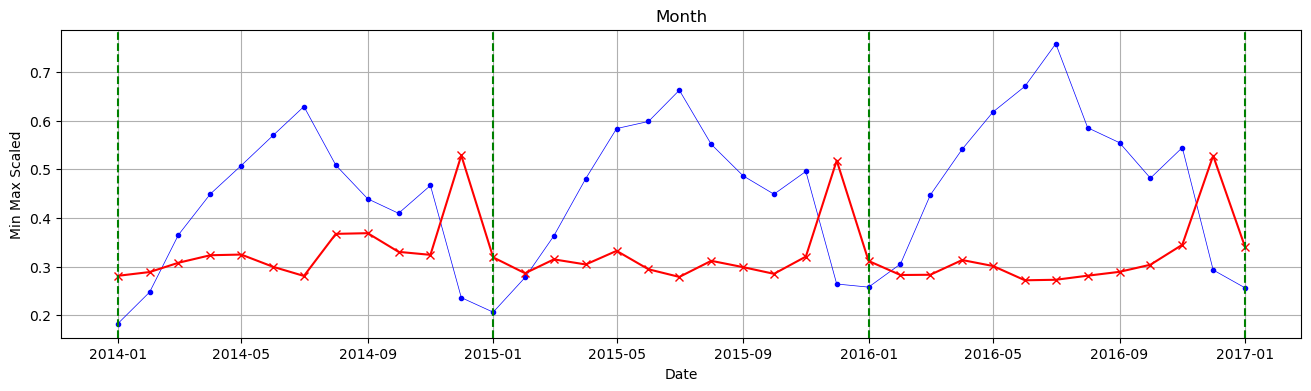

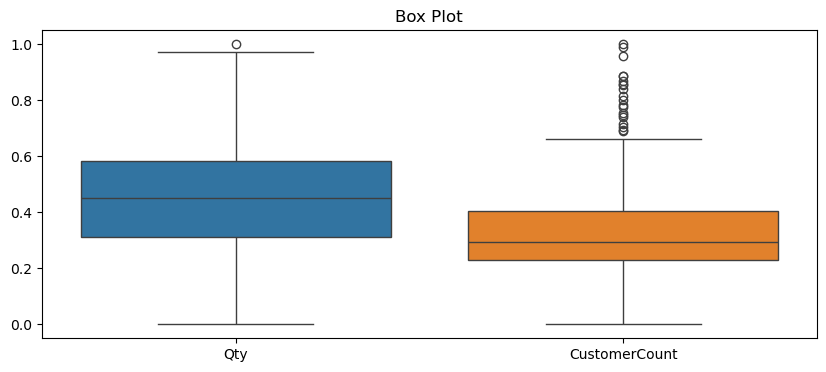

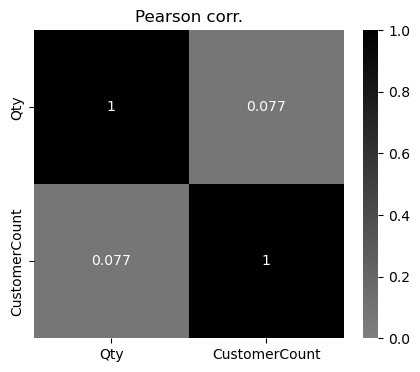

In [329]:
orders_ = orders.copy()
store_id = 44
product_id = 42
sdate = '2014-01-01'
edate = '2017-01-31'
plot_1_4(orders_, products, store_id, product_id, sdate, edate, df_Agr,figpath)

## **(2) 시계열 패턴 찾아보기2**

* 변화량과 비교해보기

### 1) 대상 매장(44), 대상 상품의 판매량 추이

#### 함수

In [425]:
# 판매량 변화량 계산 (날짜별 판매량 차이)
def plot_2_1(df1, name, sdate, edate, step, figpath):
    #df = MinMaxScaler().fit_transform(df1)
    #df = pd.DataFrame(df, columns=df1.columns, index=df1.index)
    df = df1.copy()
    daily_sales_change = df.diff(step).fillna(0)
    df_daily = daily_sales_change.copy()
    df = df.loc[sdate:edate]
    len_date = len(df)
    daily_sales_change = daily_sales_change.iloc[step:len_date+step]
    '''plt.figure(figsize=(8, 4))
    plt.plot(df.index, df, label='Total Sales (Qty)', color='green', linewidth=1)
    plt.plot(df.index, daily_sales_change, label='Sales Change (Qty)', color='red', linestyle='--', linewidth=1)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales (Qty)', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.title(f'{name}_diff_step{step}')
    plt.legend()
    plt.savefig(f'{figpath}/{name}_diff_step{step}.png')
    plt.show()
    plt.close()'''

    return daily_sales_change

In [427]:
def plot_2_1v2(df1, name, sdate, edate, step, figpath):
    df = df1.copy()
    daily_sales_change = df.shift(step).fillna(0)
    df_daily = daily_sales_change.copy()
    df = df.loc[sdate:edate]
    len_date = len(df)
    daily_sales_change = daily_sales_change.iloc[step:len_date+step]

    return daily_sales_change

In [429]:
# 판매량 변화량 계산 (날짜별 판매량 차이)
def plot_2_1v3(df1, name, sdate, edate, step, figpath):
    #df = MinMaxScaler().fit_transform(df1)
    #df = pd.DataFrame(df, columns=df1.columns, index=df1.index)
    df = df1.copy()
    daily_sales_change = df.diff(-step).fillna(0)
    df_daily = daily_sales_change.copy()
    df = df.loc[sdate:edate]
    len_date = len(df)
    daily_sales_change = daily_sales_change.iloc[step:len_date+step]

    return daily_sales_change

In [431]:
# 판매량 변화량 계산 (날짜별 판매량 차이)
def plot_2_1v4(df1, name, sdate, edate, step, figpath):
    #df = MinMaxScaler().fit_transform(df1)
    #df = pd.DataFrame(df, columns=df1.columns, index=df1.index)
    df = df1.copy()
    daily_sales_change = df.shift(-step).fillna(0)
    df_daily = daily_sales_change.copy()
    df = df.loc[sdate:edate]
    len_date = len(df)
    daily_sales_change = daily_sales_change.iloc[step:len_date+step]

    return daily_sales_change

#### 데이터 별 결과

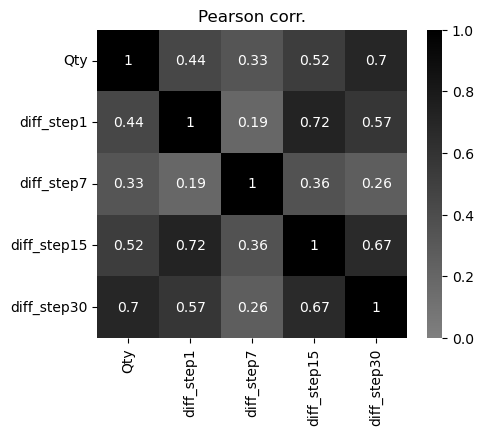

In [450]:
sdate = '2014-01-01'
edate = '2016-06-30'
steps = [1, 7, 15, 30]
temp = []
df_ = df_Bev.copy()
for i in steps:
    daily_sales_change =daily_sales_change = plot_2_1(df_Bev, 'Beverage', sdate, edate, i, figpath)
    df_[f'diff_step{i}'] = daily_sales_change
plt.figure(figsize=(5, 4))
sns.heatmap(abs(df_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
plt.title('Pearson corr.')
plt.show()

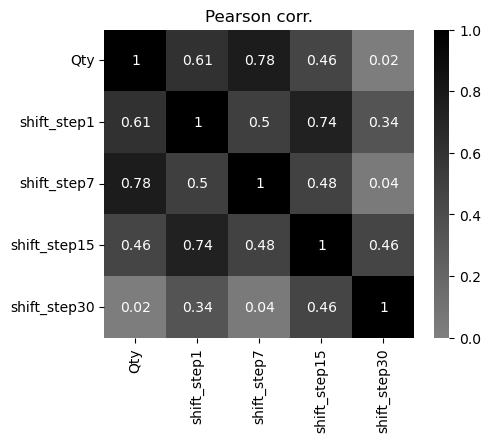

In [458]:
sdate = '2014-01-01'
edate = '2016-06-30'
steps = [1, 7, 15, 30]
temp = []
df_ = df_Bev.copy()
for i in steps:
    daily_sales_change = plot_2_1v2(df_Bev, 'Beverage', sdate, edate, i, figpath)
    df_[f'shift_step{i}'] = daily_sales_change
plt.figure(figsize=(5, 4))
sns.heatmap(abs(df_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
plt.title('Pearson corr.')
plt.show()

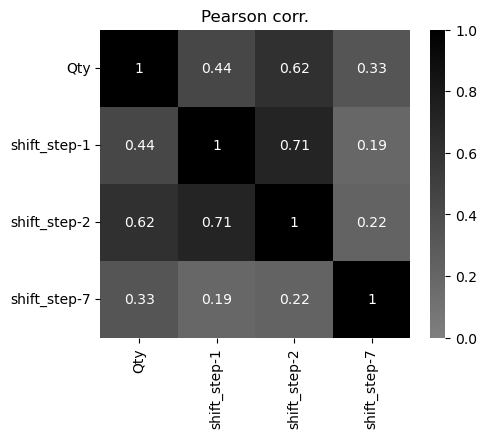

In [464]:
sdate = '2014-01-01'
edate = '2016-06-30'
steps = [1, 2, 7]
temp = []
df_ = df_Bev.copy()
for i in steps:
    daily_sales_change = plot_2_1v3(df_Bev, 'Beverage', sdate, edate, i, figpath)
    df_[f'shift_step-{i}'] = daily_sales_change
plt.figure(figsize=(5, 4))
sns.heatmap(abs(df_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
plt.title('Pearson corr.')
plt.show()

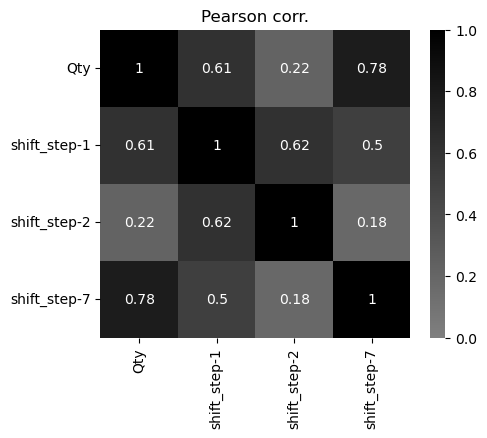

In [465]:
sdate = '2014-01-01'
edate = '2016-06-30'
steps = [1, 2, 7]
temp = []
df_ = df_Bev.copy()
for i in steps:
    daily_sales_change = plot_2_1v4(df_Bev, 'Beverage', sdate, edate, i, figpath)
    df_[f'shift_step-{i}'] = daily_sales_change
plt.figure(figsize=(5, 4))
sns.heatmap(abs(df_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
plt.title('Pearson corr.')
plt.show()

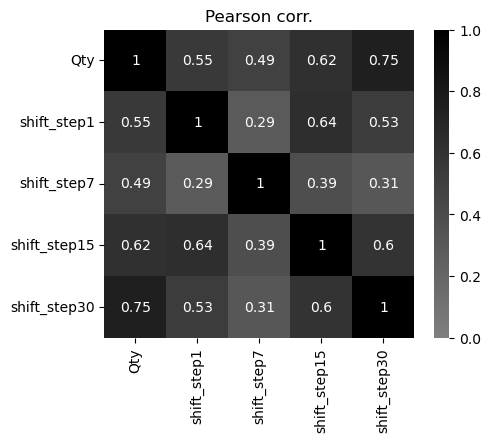

In [468]:
sdate = '2014-01-01'
edate = '2016-06-30'
steps = [1, 7, 15, 30]
df_ = df_Milk.copy()
for i in steps:
    daily_sales_change =plot_2_1(df_Milk, 'Milk', sdate, edate, i, figpath)
    df_[f'shift_step{i}'] = daily_sales_change
plt.figure(figsize=(5, 4))
sns.heatmap(abs(df_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
plt.title('Pearson corr.')
plt.show()

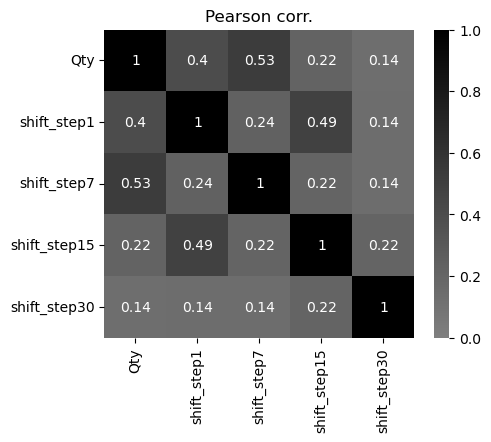

In [490]:
sdate = '2014-01-01'
edate = '2016-06-30'
steps = [1, 7, 15, 30]
df_ = df_Milk.copy()
for i in steps:
    daily_sales_change =plot_2_1v2(df_Milk, 'Milk', sdate, edate, i, figpath)
    df_[f'shift_step{i}'] = daily_sales_change
plt.figure(figsize=(5, 4))
sns.heatmap(abs(df_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
plt.title('Pearson corr.')
plt.show()

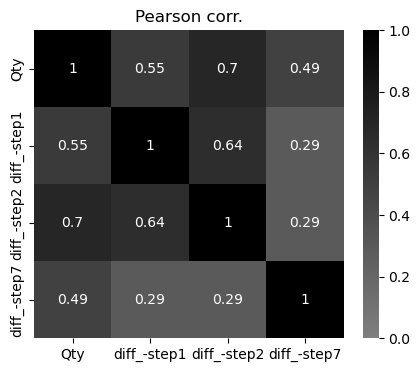

In [472]:
sdate = '2014-01-01'
edate = '2016-06-30'
steps = [1,2,7]
df_ = df_Milk.copy()
for i in steps:
    daily_sales_change =plot_2_1v3(df_Milk, 'Milk', sdate, edate, i, figpath)
    df_[f'diff_-step{i}'] = daily_sales_change
plt.figure(figsize=(5, 4))
sns.heatmap(abs(df_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
plt.title('Pearson corr.')
plt.show()

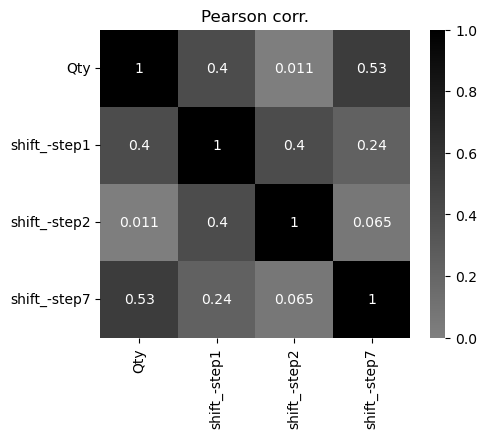

In [474]:
sdate = '2014-01-01'
edate = '2016-06-30'
steps = [1,2,7]
df_ = df_Milk.copy()
for i in steps:
    daily_sales_change =plot_2_1v4(df_Milk, 'Milk', sdate, edate, i, figpath)
    df_[f'shift_-step{i}'] = daily_sales_change
plt.figure(figsize=(5, 4))
sns.heatmap(abs(df_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
plt.title('Pearson corr.')
plt.show()

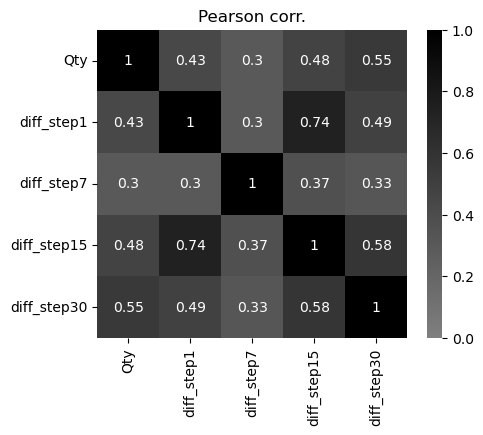

In [476]:
sdate = '2014-01-01'
edate = '2016-06-30'
steps = [1, 7, 15, 30]
df_ = df_Agr.copy()
for i in steps:
    daily_sales_change =plot_2_1(df_Agr, 'Agriculture', sdate, edate, i, figpath)
    df_[f'diff_step{i}'] = daily_sales_change
plt.figure(figsize=(5, 4))
sns.heatmap(abs(df_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
plt.title('Pearson corr.')
plt.show()

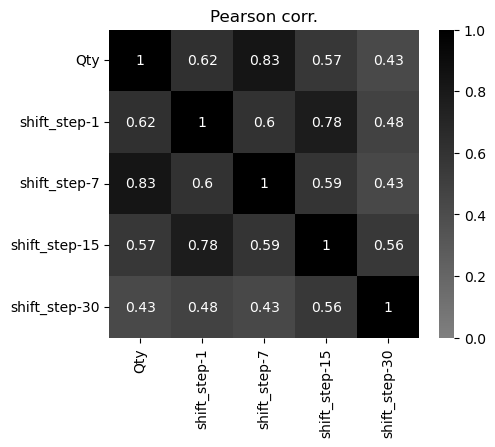

In [494]:
sdate = '2014-01-01'
edate = '2016-06-30'
steps = [1, 7, 15, 30]
df_ = df_Agr.copy()
for i in steps:
    daily_sales_change =plot_2_1v2(df_Agr, 'Agriculture', sdate, edate, i, figpath)
    df_[f'shift_step-{i}'] = daily_sales_change
plt.figure(figsize=(5, 4))
sns.heatmap(abs(df_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
plt.title('Pearson corr.')
plt.show()

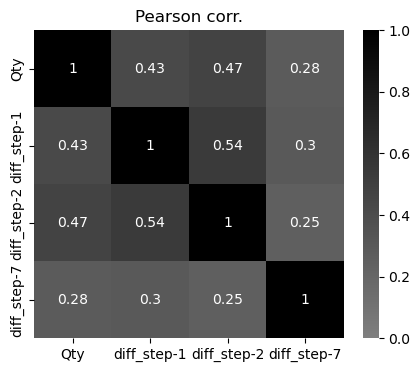

In [496]:
sdate = '2014-01-01'
edate = '2016-06-30'
steps = [1, 2, 7]
df_ = df_Agr.copy()
for i in steps:
    daily_sales_change = plot_2_1v3(df_Agr, 'Agriculture', sdate, edate, i, figpath)
    df_[f'diff_step-{i}'] = daily_sales_change
plt.figure(figsize=(5, 4))
sns.heatmap(abs(df_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
plt.title('Pearson corr.')
plt.show()

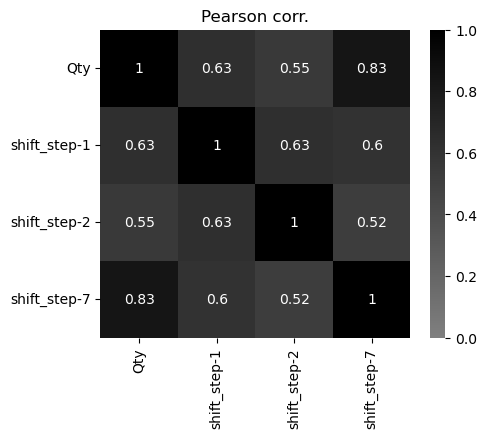

In [498]:
sdate = '2014-01-01'
edate = '2016-06-30'
steps = [1, 2, 7]
df_ = df_Agr.copy()
for i in steps:
    daily_sales_change = plot_2_1v4(df_Agr, 'Agriculture', sdate, edate, i, figpath)
    df_[f'shift_step-{i}'] = daily_sales_change
plt.figure(figsize=(5, 4))
sns.heatmap(abs(df_.corr()), vmax=1, vmin=0, annot=True, cmap='gray_r', center=0)
plt.title('Pearson corr.')
plt.show()

### 2) 요일별 변화량 비교

#### 함수

In [356]:
def plot_2_2(df1, name, sdate, edate, figpath):
    df6 = df1.copy()
    df6 = df6.loc[sdate:edate]
    df6['dow'] = df6.index.dayofweek
    df6['dow'] = df6['dow'].map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})
    dow_list = df6['dow'].unique()
    df6 = df6.groupby('dow').mean().T
    df6 = df6[['Mon', 'Tue','Wed', 'Thu', 'Fri', 'Sat', 'Sun']]
    plt.figure(figsize=(8, 5))
    plt.bar(height = df6.loc['Qty'], x = ['Mon', 'Tue','Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    plt.title(f'Day of Week {name}')
    plt.savefig(f'{figpath}/Day of Week {name}.png')
    plt.show()

#### 데이터 별 결과

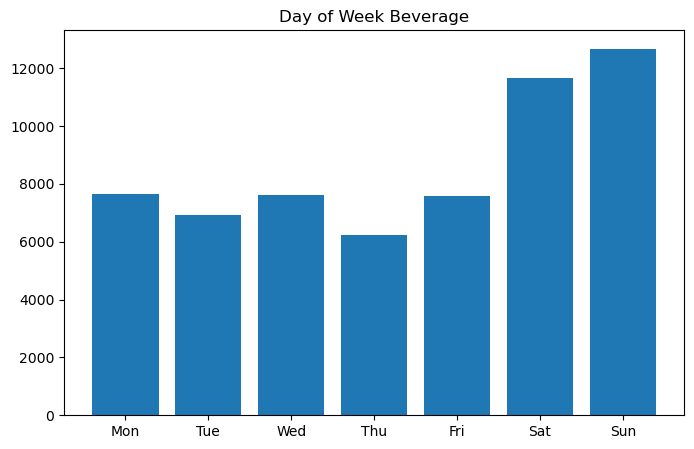

In [359]:
sdate = '2014-01-01'
edate = '2016-12-31'
plot_2_2(df_Bev, 'Beverage', sdate, edate, figpath)

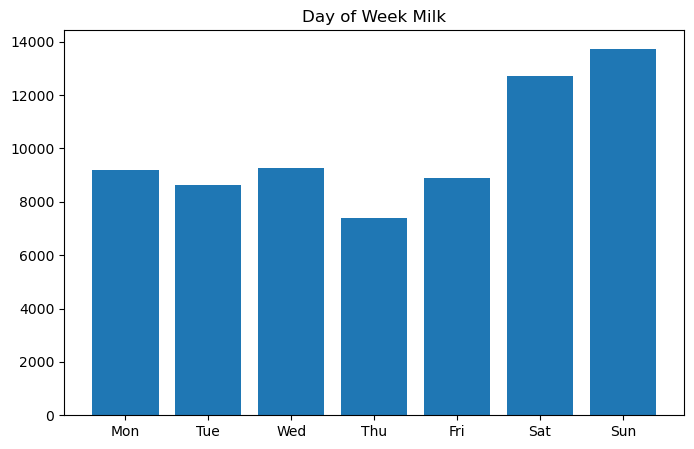

In [360]:
sdate = '2014-01-01'
edate = '2016-12-31'
plot_2_2(df_Milk, 'Milk', sdate, edate, figpath)

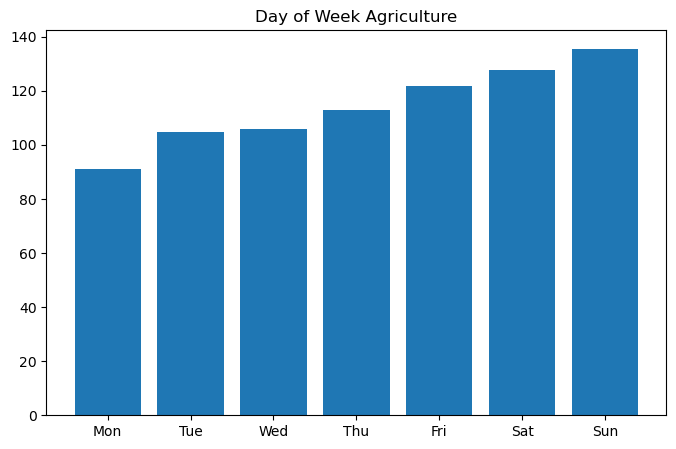

In [363]:
sdate = '2014-01-01'
edate = '2016-12-31'
plot_2_2(df_Agr, 'Agriculture', sdate, edate, figpath)

### 3) 시계열 데이터 분해

#### 함수

In [367]:
def decomp_plot(Product_ID, sdate, edate, period, name, figpath):

    # 시계열 데이터 분해
    temp = sales.loc[(sales['Store_ID'] == 44) & (sales['Product_ID'] == Product_ID) & (sales['Date'].between(sdate, edate))]
    temp.set_index('Date', inplace=True)
    decomp = sm.tsa.seasonal_decompose(temp['Qty'], model = 'additive', period = period)

    # 시계열 분해 결과를 받아서 데이터프레임으로 저장
    result = pd.DataFrame({'observed':decomp.observed, 'trend':decomp.trend, 'seasonal':decomp.seasonal, 'residual':decomp.resid})

    # 4개의 그래프로 나눠서 그리기
    plt.figure(figsize=(10, 6))

    plt.subplot(4,1,1)
    plt.plot(result['observed'])
    plt.ylabel('observed')

    plt.subplot(4,1,2)
    plt.plot(result['trend'])
    plt.ylabel('trend')

    plt.subplot(4,1,3)
    plt.plot(result['seasonal'])
    plt.ylabel('seasonal')

    plt.subplot(4,1,4)
    plt.plot(result['residual'])
    plt.ylabel('residual')

    plt.tight_layout()
    plt.savefig(f'{figpath}/{name}_decomp.png')
    plt.show()

    return result

#### 데이터 별 결과
 * observed: 관측치
 * trend: 추세
 * seasonal: 계절성
 * residual: 잔차

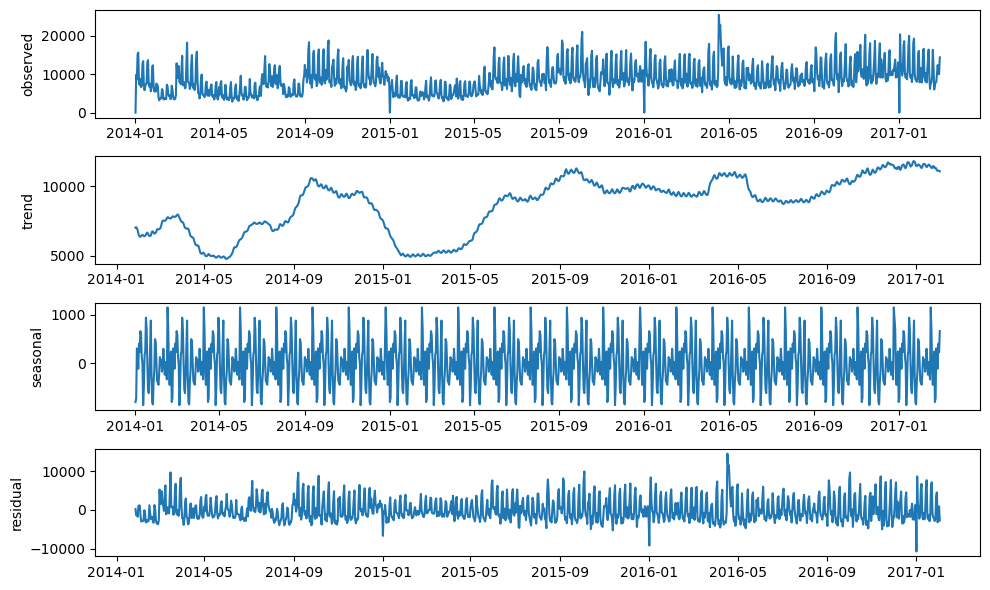

In [370]:
result = decomp_plot(3, '2014-01-01', '2017-12-31', 52, 'Beverge', figpath)

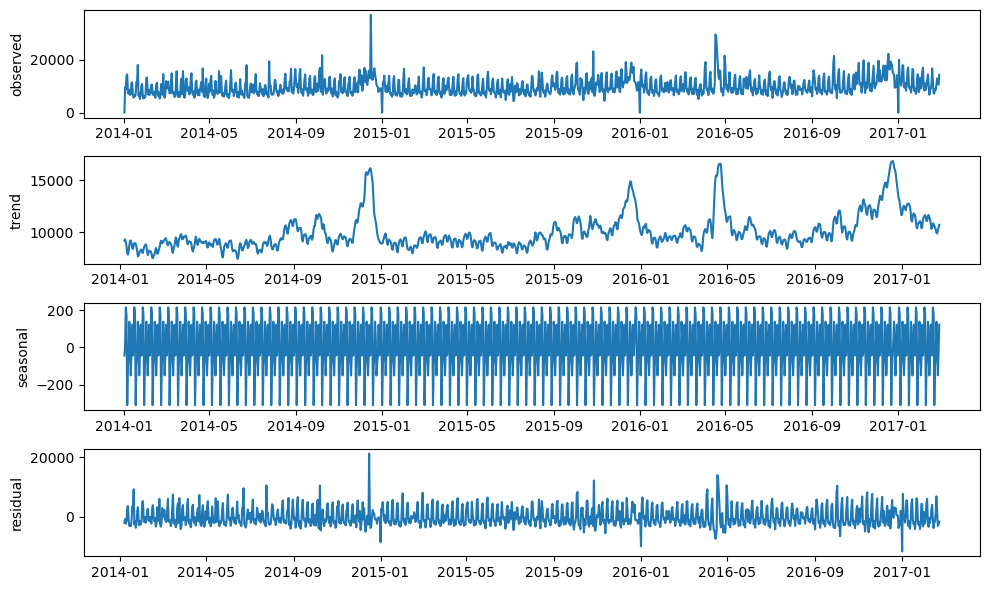

In [371]:
result = decomp_plot(12, '2014-01-01', '2017-12-31', 12, 'Milk', figpath)

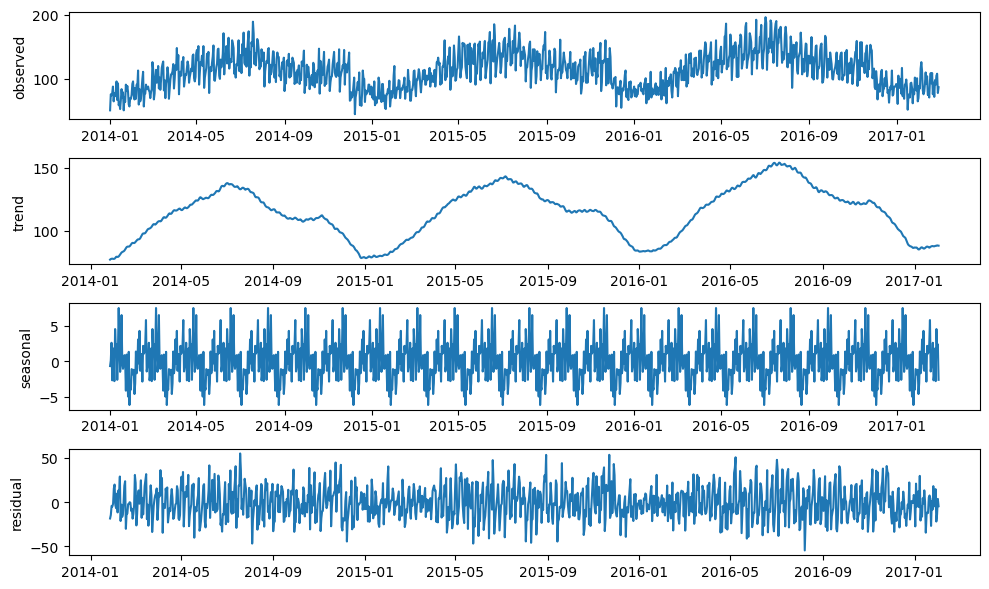

In [372]:
result = decomp_plot(42, '2014-01-01', '2017-12-31', 52, 'Agriculural', figpath)

## (3) 그 외 패턴 찾아보기

### 1) 지역 별 판매량

#### 필요한 파일 다운로드

In [ ]:
!pip install -qq shapely
!pip install -qq matplotlib-scalebar

In [ ]:
pip install geopy

   ---------------------------------------- 0.0/125.4 kB ? eta -:--:--
   --------- ------------------------------ 30.7/125.4 kB ? eta -:--:--
   ---------------------------------------- 125.4/125.4 kB 2.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/40.3 kB ? eta -:--:--
   ---------------------------------------- 40.3/40.3 kB 1.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [375]:
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib as mpl
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import Rectangle
from shapely.geometry.point import Point
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.path import Path
from geopy.distance import geodesic
import math

import requests
import zipfile
import io
import geopandas as gpd
from shapely.geometry import MultiPolygon, Polygon

In [376]:
# if first_ == True:
# 파일 URL
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_USA_shp.zip"

# 파일 다운로드
response = requests.get(url)
if response.status_code == 200:
    # ZIP 파일 열기
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        # 모든 파일 압축 해제 (현재 디렉터리에 저장됨)
        z.extractall("shapefiles")
    print("파일이 성공적으로 다운로드 및 압축 해제되었습니다.")
else:
    print(f"파일 다운로드에 실패했습니다. 상태 코드: {response.status_code}")

파일이 성공적으로 다운로드 및 압축 해제되었습니다.


#### 지도 편집을 위한 함수 추가

In [378]:
def deg_to_dms(deg):
    d = int(deg)
    m = int((deg - d) * 60)
    s = (deg - d - m / 60) * 3600
    return f"{abs(d)}°{abs(m)}\'{abs(s):.1f}\"{'S' if deg < 0 else 'N'}" if d == 0 else f"{abs(d)}°{abs(m)}\'{abs(s):.1f}\"{'W' if deg < 0 else 'E'}"

def longitude_formatter(x, pos):
    return deg_to_dms(x)

def latitude_formatter(y, pos):
    return deg_to_dms(y)

def meters_formatter(x, p):
    strRes = '{:,}m'.format(int(x))
    return strRes

def northArrowPatch(x,y,width,height,ax,trans):
    verts = []
    codes = []
    for part in range(0,4):
        if part == 0:
            verts.append((x,y))
            codes.append(Path.MOVETO)
        if part == 1:
            verts.append((x+(width/2.0),y-(height)))
            codes.append(Path.LINETO)
        if part == 2:
            verts.append((x,y-(height-(1.0/5.0)*height)))
            codes.append(Path.LINETO)
        if part == 3:
            verts.append((x-(width/2.0),y-(height)))
            codes.append(Path.LINETO)
            verts.append((x,y))
            codes.append(Path.CLOSEPOLY)

    path = Path(verts, codes)
    northPatch = mpatches.PathPatch(path, facecolor='k', lw=0,transform=trans)
    ax.add_patch(northPatch)
    lbl = ax.text(x,y+((1.0/5.0)*height),'N',transform=trans,ha='center')
    return northPatch,lbl

def scaleBar(x, y, mapdistance, ax, trans, latlon, subdivision=1, height=0.02):
    # Get the total width of the plot in data coordinates
    xmin, xmax = ax.get_xlim()  # returns left, right in transformed coordinates
    ymin, ymax = ax.get_ylim()  # returns bottom, top in transformed coordinates

    abs_width = abs(xmax - xmin)

    # Calculate the scale factor to map distances to axis coordinates
    scale_factor = abs_width/mapdistance

    # Calculate actual length in transformed coordinates for the scale bar
    length = mapdistance * scale_factor

    # If subdivision is greater than 1, we divide the scale bar into smaller parts
    if subdivision > 1:
        sublength = length / subdivision
        fColor = 'black'
        subx = x
        for i in range(subdivision):
            ax.add_patch(mpatches.Rectangle((subx, y), sublength, height, transform=trans,
                                            facecolor=fColor, edgecolor='black', lw=0.5))
            subx += sublength
            fColor = 'black' if fColor == 'white' else 'white'
    else:
        # Single bar without subdivision
        ax.add_patch(mpatches.Rectangle((x, y), length, height, transform=trans,
                                        facecolor='black', edgecolor='black'))

    # Add text labels (0 and mapdistance at the ends)
    ax.text(x, y + height * 1.5, '0', transform=trans, ha='center')
    ax.text(x + length, y + height * 1.5, meters_formatter(mapdistance, None),
            transform=trans, ha='center')

    # To update distance calculation for `EPSG: 4326`, adjust distance with geodesic
    # Use geopy to calculate the actual geographic distance for the scale bar.
    # Let's assume the scale bar length should correspond to a real-world distance.
    geodesic_distance = geodesic((latlon[0], latlon[1]), (latlon[0], latlon[1] + (mapdistance / 111320000))).km  # approx
    scale_label = meters_formatter2(geodesic_distance, None)  # convert to meters

    return scale_label

def meters_formatter2(value, unit=None):
    """Formatter for meters (adds unit or default formatting)"""
    if unit is None:
        return f"{value:.2f} km"
    else:
        return f"{value:.2f} {unit}"

#### 함수

In [181]:
pop = pd.read_json(path+'us-states.json')
pop

,ID State,State,ID Year,Year,Population,Slug State
0,04000US01,Alabama,2019,2019,4903185,alabama
1,04000US02,Alaska,2019,2019,731545,alaska
2,04000US04,Arizona,2019,2019,7278717,arizona
3,04000US05,Arkansas,2019,2019,3017804,arkansas
4,04000US06,California,2019,2019,39512223,california
...,...,...,...,...,...,...
359,04000US53,Washington,2013,2013,6971406,washington
360,04000US54,West Virginia,2013,2013,1854304,west-virginia
361,04000US55,Wisconsin,2013,2013,5742713,wisconsin
362,04000US56,Wyoming,2013,2013,582658,wyoming


In [183]:
gdf = gpd.read_file(c_path+'shapefiles/gadm41_USA_1.shp')
pop = pd.read_json(path+'us-states.json')

In [382]:
# 주어진 데이터를 DataFrame으로 구성
def GIS_plot1(df, gdf, pdf, target):
    # 미국 주 지도 데이터 로드 (shapefile 필요)
    # 주의: 파일 경로는 사용자의 데이터에 맞게 설정해야 합니다.

    state_counts = df['State'].value_counts()
    state_counts.index.str.replace(r'\\', '', regex=True).str.strip()
    state_counts = pd.DataFrame(state_counts)

    pop_ = pdf.copy()
    pop_ = pop_[['State', 'Population']][pop['Year']==2015]
    pop_.set_index('State', inplace=True)

    gdf_ = gdf.copy()[['NAME_1', 'geometry']]
    gdf_.columns = ['State', 'geometry']
    gdf_.set_index('State', inplace=True)

    gdf_[target] = np.NaN
    gdf_[target] = state_counts[target]
    gdf_[target].fillna(0, inplace=True)

    pop_ = pop_.loc[gdf_.index]
    gdf_['Population'] = pop_['Population'].astype(int)
    gdf_['Population'].fillna(0, inplace=True)
    gdf_[f'{target}/Population'] = gdf_[target]/gdf_['Population']

    x1, x2, y1, y2 = -130, -65, 19, 51
    points = gpd.GeoSeries([Point(x1, y1), Point(x2, y1)], crs=4326)
    points = points.to_crs(3857)
    distance_meters = (points[0].distance(points[1]))

    target_country = gdf[gdf['NAME_1']=='Minnesota']
    target_country.to_crs(epsg=4326)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    gdf_.plot(column=f'{target}/Population', ax=ax, cmap='gray_r', edgecolor='black')

    ax.set_xlim(x1, x2)
    ax.set_ylim(y1, y2)
    ax.set_aspect('equal')

    bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    width, height = bbox.width, bbox.height
    px_width = fig.dpi * width
    dist = distance_meters
    meter_per_px = dist / px_width

    sm = plt.cm.ScalarMappable(cmap='gray_r', norm=plt.Normalize(vmin=gdf_[f'{target}/Population'].min(), vmax=gdf_[f'{target}/Population'].max()))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.1, pad=0.04)

    target_country.plot(ax=ax, edgecolor='red', linewidth=2, facecolor='none')

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=90)

    latlon = (39.8283, 98.5795)
    mapdistance = 1000000  # 1,000,000 meters (1,000 km)
    # Call the scale bar function

    nrth,lbl = northArrowPatch(0.1,0.15,0.1,0.1,ax,ax.transAxes)
    print(distance_meters)

    ax.xaxis.set_major_formatter(FuncFormatter(longitude_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(latitude_formatter))

    plt.tight_layout()
    plt.show()

    return gdf_, state_counts

In [383]:
# 주어진 데이터를 DataFrame으로 구성
def GIS_plot1v2(df, gdf, pdf, target):
    # 미국 주 지도 데이터 로드 (shapefile 필요)
    # 주의: 파일 경로는 사용자의 데이터에 맞게 설정해야 합니다.

    state_counts = df['State'].value_counts()
    state_counts.index.str.replace(r'\\', '', regex=True).str.strip()
    state_counts = pd.DataFrame(state_counts)

    pop_ = pdf.copy()
    pop_ = pop_[['State', 'Population']][pop['Year']==2015]
    pop_.set_index('State', inplace=True)

    gdf_ = gdf.copy()[['NAME_1', 'geometry']]
    gdf_.columns = ['State', 'geometry']
    gdf_.set_index('State', inplace=True)

    gdf_[target] = np.NaN
    gdf_[target] = state_counts[target]
    gdf_[target].fillna(0, inplace=True)

    pop_ = pop_.loc[gdf_.index]
    gdf_['Population'] = pop_['Population'].astype(int)
    gdf_['Population'].fillna(0, inplace=True)
    gdf_[f'{target}/Population'] = gdf_[target]/gdf_['Population']

    x1, x2, y1, y2 = -130, -65, 19, 51
    points = gpd.GeoSeries([Point(x1, y1), Point(x2, y1)], crs=4326)
    points = points.to_crs(3857)
    distance_meters = (points[0].distance(points[1]))

    target_country = gdf[gdf['NAME_1']=='Minnesota']
    target_country.to_crs(epsg=4326)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    gdf_.plot(column=f'Population', ax=ax, cmap='gray_r', edgecolor='black')

    ax.set_xlim(x1, x2)
    ax.set_ylim(y1, y2)
    ax.set_aspect('equal')

    bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    width, height = bbox.width, bbox.height
    px_width = fig.dpi * width
    dist = distance_meters
    meter_per_px = dist / px_width
    #scalebar = ScaleBar(meter_per_px, location='lower right')
    #fig.gca().add_artist(scalebar)

    sm = plt.cm.ScalarMappable(cmap='gray_r', norm=plt.Normalize(vmin=gdf_['Population'].min(), vmax=gdf_[f'Population'].max()))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.1, pad=0.04)

    target_country.plot(ax=ax, edgecolor='red', linewidth=2, facecolor='none')

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=90)

    latlon = (39.8283, 98.5795)
    mapdistance = 1000000  # 1,000,000 meters (1,000 km)
    # Call the scale bar function

    nrth,lbl = northArrowPatch(0.1,0.15,0.1,0.1,ax,ax.transAxes)
    print(distance_meters)

    ax.xaxis.set_major_formatter(FuncFormatter(longitude_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(latitude_formatter))

    plt.tight_layout()
    plt.show()

    return gdf_, state_counts

#### 데이터 적용 결과

7235766.901562782


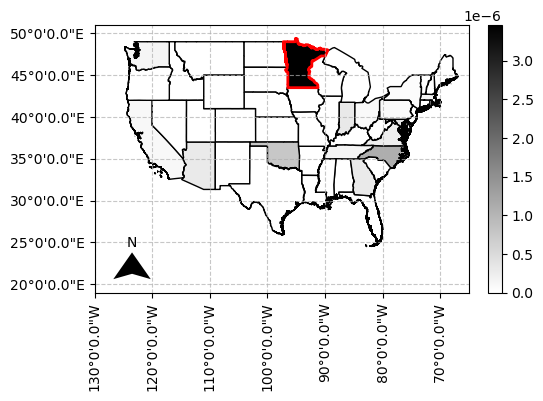

In [385]:
# 주별 Store 개수 집계
df1 = stores.copy()
pdf = pop.copy()
us_states, state_counts = GIS_plot1(df1, gdf, pdf, 'count')

7235766.901562782


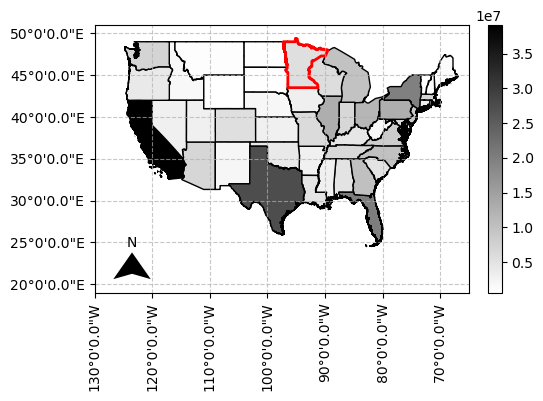

In [386]:
# 주별 Store 개수 집계
df1 = stores.copy()
pdf = pop.copy()
us_states, state_counts = GIS_plot1v2(df1, gdf, pdf, 'count')

In [387]:
pdf = pop.copy()

In [388]:
pdf.head()

,ID State,State,ID Year,Year,Population,Slug State
0,04000US01,Alabama,2019,2019,4903185,alabama
1,04000US02,Alaska,2019,2019,731545,alaska
2,04000US04,Arizona,2019,2019,7278717,arizona
3,04000US05,Arkansas,2019,2019,3017804,arkansas
4,04000US06,California,2019,2019,39512223,california


### 2) 지역별 상품 구매 현황

#### 함수

In [391]:
def GIS_plot2(df1, df2, gpd, pdf, products, target):
    state_list = list(df1['State'].unique())
    temp = []
    for state in state_list:
        store_id_list = list(df1['Store_ID'].loc[df1['State']==state].unique())
        target_num = products['Product_ID'].loc[products['SubCategory'] == target].values[0]
        df2_ = df2[(df2['Store_ID'].isin(store_id_list)) & (df2['Product_ID']==target_num)]
        temp.append(df2_['Qty'].sum()/len(store_id_list))
    data = pd.DataFrame(temp ,columns=[target],index=state_list)

    gdf_ = gdf.copy()[['NAME_1', 'geometry']]
    gdf_.columns = ['State', 'geometry']
    gdf_.set_index('State', inplace=True)

    gdf_[target] = np.NaN
    gdf_[target] = data[target]
    gdf_[target].fillna(0, inplace=True)

    pop_ = pdf.copy()
    pop_ = pop_[['State', 'Population']][pop['Year']==2015]
    pop_.set_index('State', inplace=True)
    pop_ = pop_.loc[gdf_.index]

    gdf_['Population'] = pop_['Population'].astype(int)
    gdf_['Population'].fillna(0, inplace=True)
    gdf_[f'{target}/Population'] = gdf_[target]/gdf_['Population']

    x1, x2, y1, y2 = -130, -65, 19, 51
    points = gpd.GeoSeries([Point(x1, y1), Point(x2, y1)], crs=4326)
    points = points.to_crs(3857)
    distance_meters = (points[0].distance(points[1]))

    target_country = gdf[gdf['NAME_1']=='Minnesota']
    target_country.to_crs(epsg=4326)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    gdf_.plot(column=f'{target}/Population', ax=ax, cmap='gray_r', edgecolor='black')

    ax.set_xlim(x1, x2)
    ax.set_ylim(y1, y2)
    ax.set_aspect('equal')

    bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    width, height = bbox.width, bbox.height
    px_width = fig.dpi * width
    dist = distance_meters
    meter_per_px = dist / px_width

    sm = plt.cm.ScalarMappable(cmap='gray_r', norm=plt.Normalize(vmin=gdf_[f'{target}/Population'].min(), vmax=gdf_[f'{target}/Population'].max()))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.1, pad=0.04)

    target_country.plot(ax=ax, edgecolor='red', linewidth=2, facecolor='none')

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=90)

    latlon = (39.8283, 98.5795)
    mapdistance = 1000000  # 1,000,000 meters (1,000 km)
    # Call the scale bar function

    nrth,lbl = northArrowPatch(0.1,0.15,0.1,0.1,ax,ax.transAxes)
    print(distance_meters)

    ax.xaxis.set_major_formatter(FuncFormatter(longitude_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(latitude_formatter))

    plt.tight_layout()
    plt.show()

    return gdf_

<Axes: >

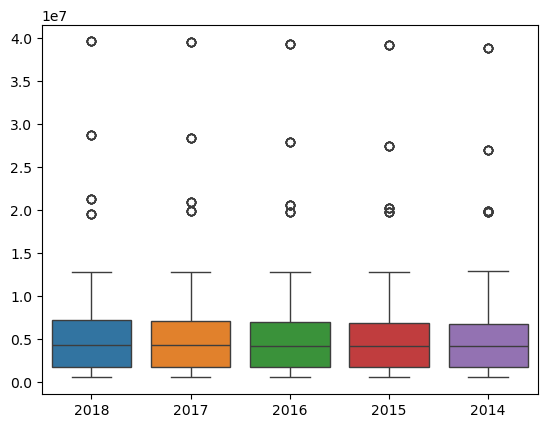

In [530]:
pdf = pop.copy()
pdf.set_index('State', inplace=True)
df_temp = pd.DataFrame(index=pdf.index)
df_temp['2018'] = pdf[pdf['Year']==2018]['Population']
df_temp['2017'] = pdf[pdf['Year']==2017]['Population']
df_temp['2016'] = pdf[pdf['Year']==2016]['Population']
df_temp['2015'] = pdf[pdf['Year']==2015]['Population']
df_temp['2014'] = pdf[pdf['Year']==2014]['Population']
sns.boxplot(df_temp)

#### 데이터 적용 결과

7235766.901562782


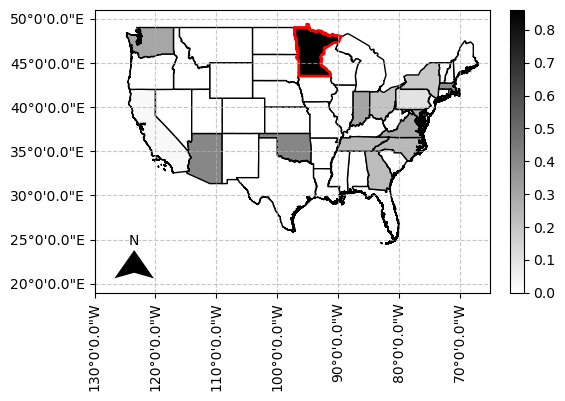

In [393]:
df1 = stores.copy()
df2 = sales.copy()
target = 'Beverage'
data = GIS_plot2(df1, df2, gpd, pdf, products, target)

7235766.901562782


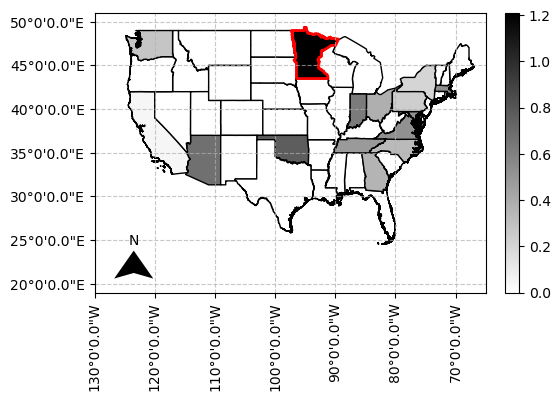

In [394]:
df1 = stores.copy()
df2 = sales.copy()
target = 'Milk'
data = GIS_plot2(df1, df2, gpd, pdf, products, target)

7235766.901562782


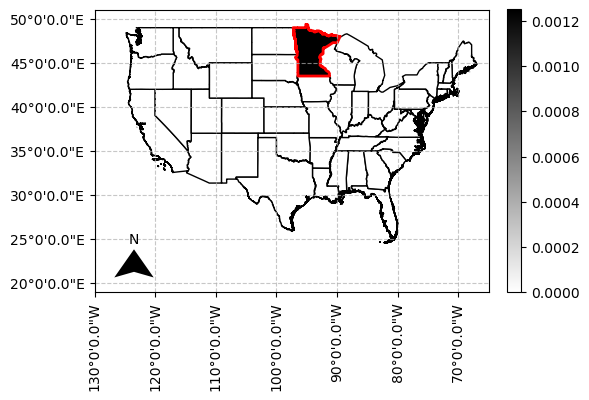

In [395]:
df1 = stores.copy()
df2 = sales.copy()
target = 'Agricultural products'
data = GIS_plot2(df1, df2, gpd, pdf, products, target)

### 3) 기상자료와 비교

#### 함수

In [402]:
def climate_plot1(store_id, product_id, cdf, sdate, edate, step, df, figpath):
    category = products[products['Product_ID']==product_id]['SubCategory'].values[0]
    df_ = df.copy()
    climate = cdf.copy()
    # climate data 1차 편집: 기온만 가져옴
    climate['Date'] = pd.to_datetime(climate['Date'] )
    climate = climate.set_index('Date')
    climate.replace('T', np.nan, inplace=True)
    climate = climate.astype('float64')
    climate = climate.interpolate(method='linear')
    climate = climate.fillna(0)
    climate = climate[['Maximum Temperature degrees (F)', 'Minimum Temperature degrees (F)', 'Precipitation (inches)']]

    temp = {}
    climate_ = pd.DataFrame(temp, columns=['Max Temp', 'Min Temp'])
    climate_[['Max Temp', 'Min Temp']] = climate[['Maximum Temperature degrees (F)', 'Minimum Temperature degrees (F)']].loc[sdate:edate]

    # Climate data 2차 편집: 누적 강수량을 가져옴
    climate_['Precipitation (inches)'] = climate['Precipitation (inches)']
    climate_[f'accum{30}.Prec.'] = climate['Precipitation (inches)'].rolling(window=30).sum()
    climate_[f'accum{60}.Prec.'] = climate['Precipitation (inches)'].rolling(window=60).sum()
    climate_[f'accum{90}.Prec.'] = climate['Precipitation (inches)'].rolling(window=90).sum()
    climate_[f'accum{120}.Prec.'] = climate['Precipitation (inches)'].rolling(window=120).sum()

    # Qty 데이터와 결합
    climate_[f'{category}_Qty'] = df['Qty'].loc[sdate:edate]
    data =climate_.copy()

    names = data.columns
    df2_s = MinMaxScaler().fit_transform(data)
    df2_s = pd.DataFrame(df2_s, columns=data.columns, index=data.index)
    df2_s_M = df2_s[names].resample('MS').mean()

    plt.figure(figsize=(8, 4))
    for col in names:
        plt.plot(df2_s[col], label=col, marker='o', linestyle='-', linewidth=0.5,markersize=3)
    for year in df2_s.index.year.unique():
        plt.axvline(pd.Timestamp(f'{year}-01-01'), color='green', linestyle='--', linewidth=1.5) # 연도별 구분선 추가
        ax = plt.gca()
        xticks = ax.get_xticks()
        xticks_dates = [mdates.num2date(tick).strftime('%Y-%m-%d') for tick in xticks]
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3, bymonth=[1, 4, 7, 10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        xticks_dates[-1] = (f'{edate[:-3]}-01')
        plt.xticks(xticks_dates, fontsize=10)
        plt.yticks(fontsize=10)
        plt.xlabel('Qty')
        plt.ylabel('Date')
    plt.legend()
    plt.grid(True)
    plt.title(f'{category}_Daily_Scaled')
    plt.tight_layout()
    plt.savefig(f'{figpath}/{category}_Daily_scaled_Climate.png')
    plt.show()
    plt.close()

    plt.figure(figsize=(8, 4))
    for col in names:
        plt.plot(df2_s_M[col], label=col, marker='o', linestyle='-', linewidth=0.5,markersize=3)
    for year in df2_s_M.index.year.unique():
        plt.axvline(pd.Timestamp(f'{year}-01-01'), color='green', linestyle='--', linewidth=1.5) # 연도별 구분선 추가
        ax = plt.gca()
        xticks = ax.get_xticks()
        xticks_dates = [mdates.num2date(tick).strftime('%Y-%m-%d') for tick in xticks]
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3, bymonth=[1, 4, 7, 10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        xticks_dates[-1] = (f'{edate[:-3]}-01')
        plt.xticks(xticks_dates, fontsize=10)
        plt.yticks(fontsize=10)
        plt.xlabel('Qty')
        plt.ylabel('Date')
    plt.legend()
    plt.grid(True)
    plt.title(f'{category}_Mean_Scaled')
    plt.tight_layout()
    plt.savefig(f'{figpath}/{category}_Year_scaled_Climate.png')
    plt.show()
    plt.close()

    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df2_s)
    plt.title('Box Plot')
    plt.xticks(rotation=45)
    plt.savefig(f'{figpath}/{category}_Climate_box.png')
    plt.show()
    plt.close()

    plt.figure(figsize=(5, 4))
    sns.heatmap(abs(df2_s.corr()), vmax=1, vmin=0, fmt='.2f', annot=True, cmap='gray_r', center=0)
    plt.title('Pearson corr.')
    plt.savefig(f'{figpath}/{category}_Climate_heatmap_pearson.png')
    plt.show()
    plt.close()

    '''plt.figure(figsize=(5, 4))
    sns.heatmap(df2_s.corr(method='spearman'), vmax=1, vmin=0, fmt='.2f',annot=True, cmap='gray_r', center=0)
    plt.title('Spearman corr.')
    plt.savefig(f'{figpath}/{category}_Climate_heatmap_spearman.png')
    plt.show()
    plt.close()'''
    return data

#### 데이터 적용 결과

In [404]:
cdf = pd.read_csv(path + 'Climate data.csv')

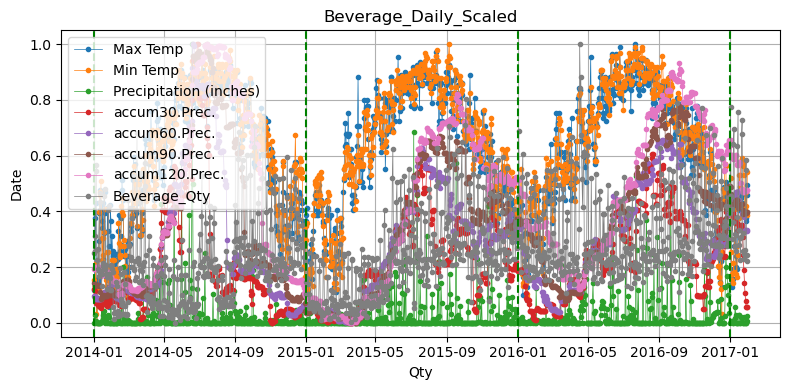

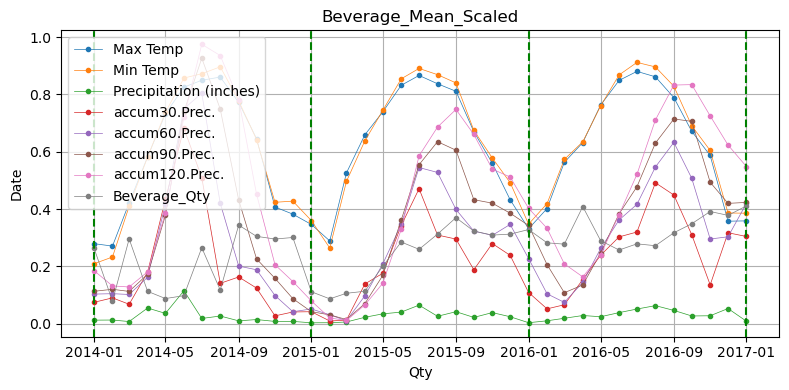

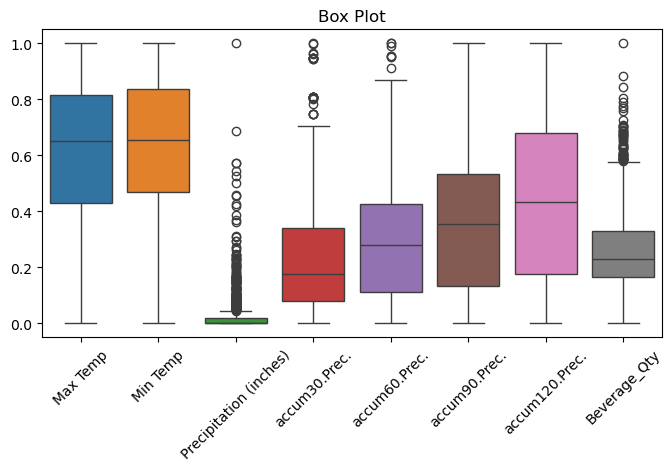

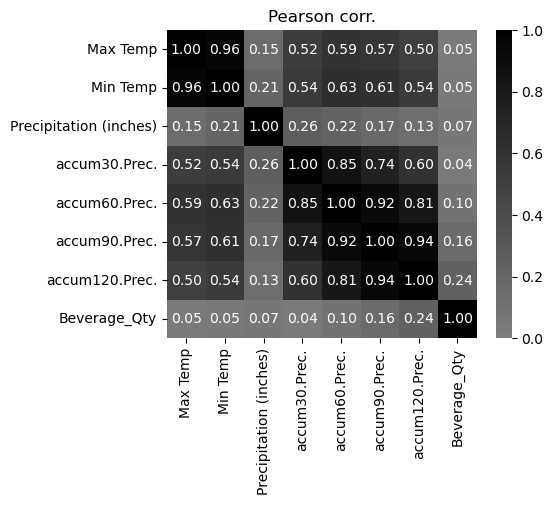

In [405]:
store_id = 44
product_id = 3
sdate = '2014-01-01'
edate = '2017-01-31'
step = 30

climate_Bev = climate_plot1(store_id, product_id, cdf, sdate, edate, step, df_Bev, figpath)
climate_Bev.to_csv(path+'climate_Bev.csv')

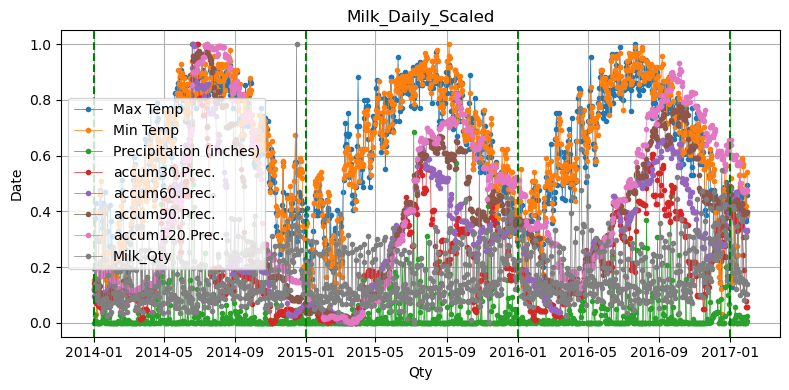

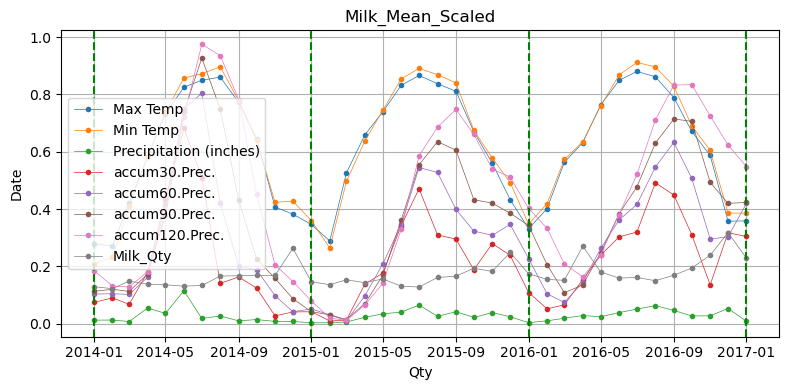

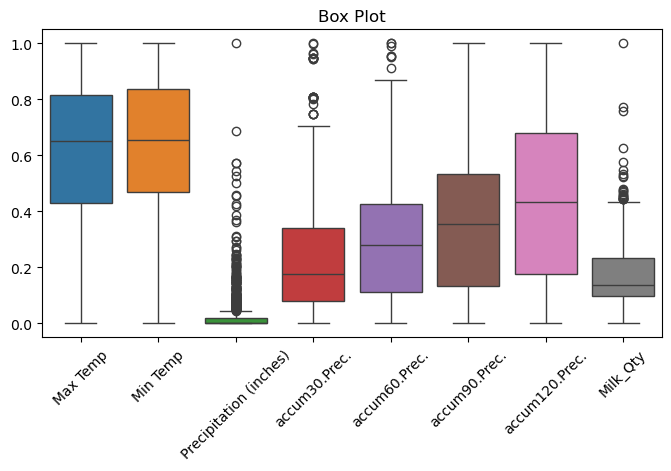

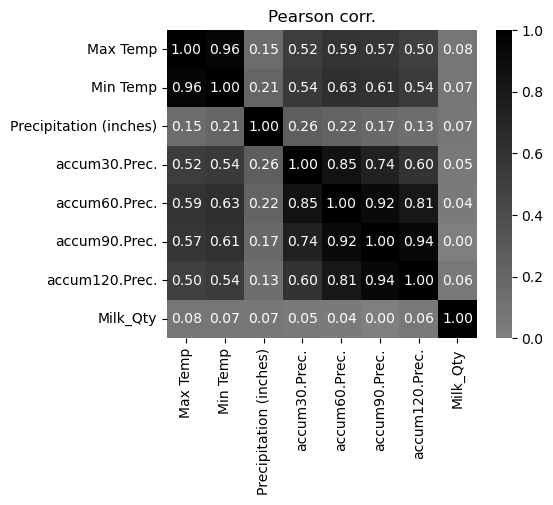

In [406]:
store_id = 44
product_id = 12
sdate = '2014-01-01'
edate = '2017-01-31'
step = 365

climate_Milk = climate_plot1(store_id, product_id, cdf, sdate, edate, step, df_Milk, figpath)
climate_Milk.to_csv(path + 'climate_Milk.csv')

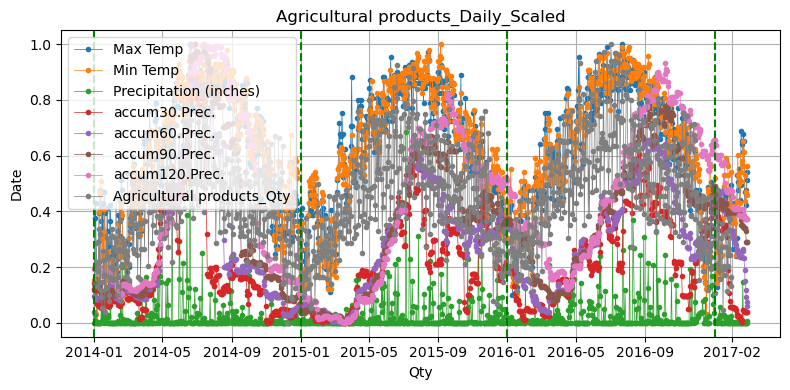

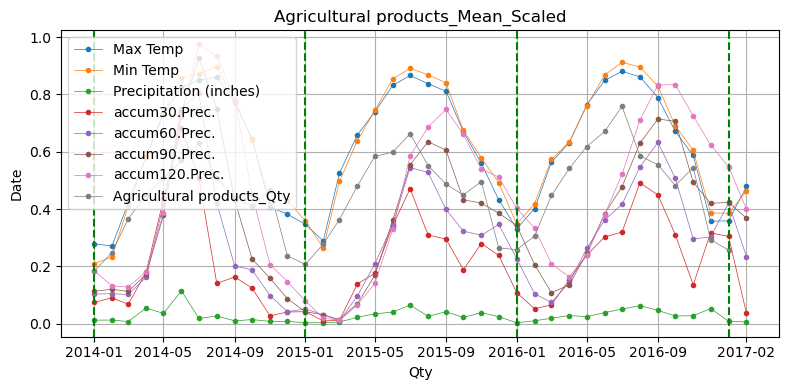

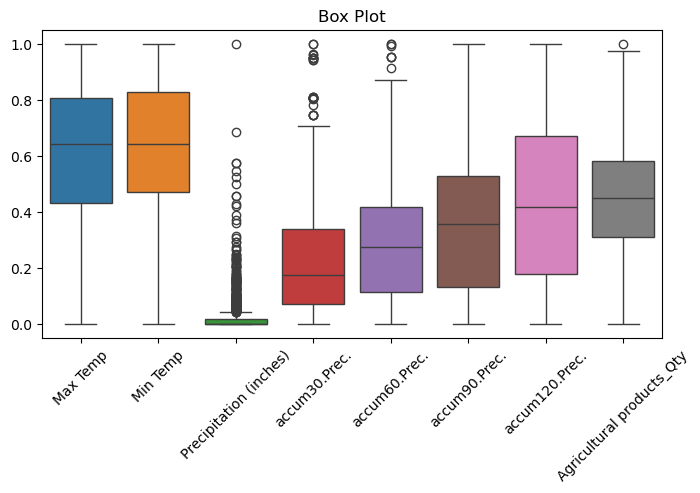

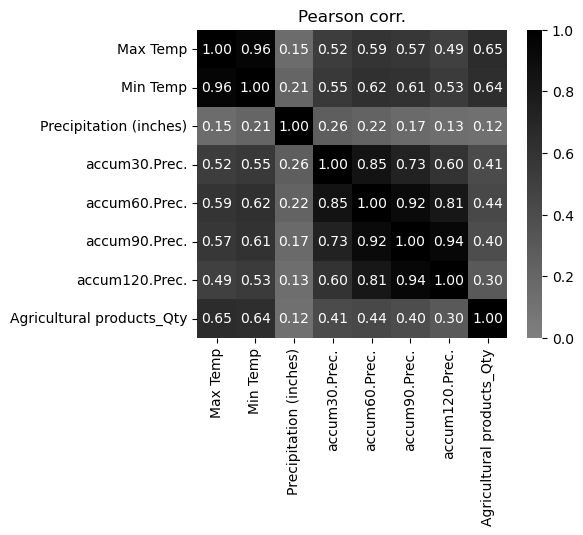

In [407]:
store_id = 44
product_id = 42
sdate = '2014-01-01'
edate = '2017-02-28'
step = 90
climate_Arg = climate_plot1(store_id, product_id, cdf, sdate, edate, step, df_Agr, figpath)
climate_Arg.to_csv(path + 'climate_Arg.csv')


In [574]:
chart_df

,Max Temp,Min Temp,Precipitation (inches),accum30.Prec.,accum60.Prec.,accum90.Prec.,accum120.Prec.
Beverage_Qty,0.045186,0.047048,0.067959,0.039394,0.095957,0.159222,0.237570
Milk_Qty,0.075603,0.074956,0.066069,0.048193,0.040884,0.001466,0.059277
Agricultural products_Qty,0.650883,0.637620,0.119440,0.408530,0.435701,0.396060,0.299946


<Axes: >

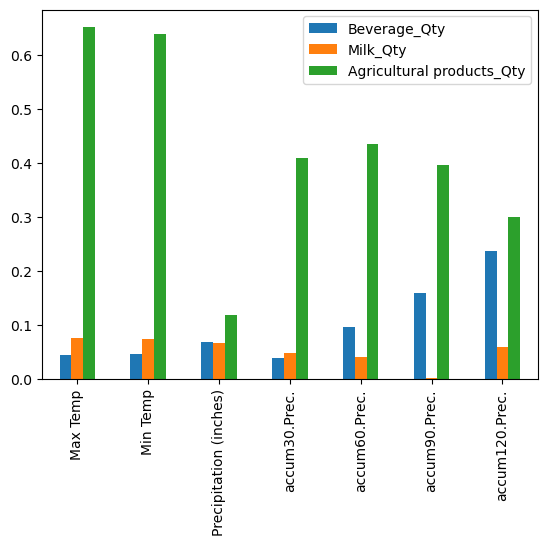

In [596]:
climate_temp = climate_Bev.copy()
climate_temp['Milk_Qty'] = climate_Milk['Milk_Qty']
climate_temp['Agricultural products_Qty'] = climate_Arg['Agricultural products_Qty']
climate_corr = climate_temp.corr()[['Beverage_Qty', 'Milk_Qty', 'Agricultural products_Qty']]
chart_df = climate_corr.loc['Max Temp': 'accum120.Prec.'].abs()
chart_df.plot.bar()

#### 필요한 데이터 수집

In [ ]:
# first_ = False
# import requests
# import zipfile
# import io
# from tqdm import tqdm

# if first_ == True:
#     for d in tqdm(dt):
#         # 파일 URL
#         url = f"https://droughtmonitor.unl.edu/DmData/GISData.aspx?mode=table&aoi=state&date={d}"

#         # 파일 다운로드
#         response = requests.get(url)
#     dt = data.loc['2014-01-07':].index.strftime('%Y%m%d')
#     dt = [dt[i] for i in range(0, len(dt), 7)]

# **3.패턴 정리하기**

* 다양한 탐색을 통해 찾은 시계열 패턴을 적어 봅시다.